# Acoustic Scattering Lab — Experiment Guide

This notebook documents twelve reproducible experiments using the MPDOK 2D Helmholtz BEM solver.  
Each experiment can be run here **programmatically** and replicated interactively in the **Acoustic Lab UI** (`server.py`).

## What the physics engine does

- Solves the 2D Helmholtz equation `(∇² + k²)p = 0` for a plane wave scattered by one or more obstacles
- **Sound-soft (BC: Soft)** — pressure-release boundary: `p = 0` on surface (e.g. open-cell foam, water surface, vegetation)
- **Sound-hard (BC: Hard)** — rigid-wall boundary: `∂p/∂n = 0` on surface (e.g. concrete wall, steel pole, tree trunk)
- Wavenumber `k = 2π/λ`; frequency `f = kc/(2π)` at speed of sound c = 343 m/s
- Domain shown is ±6 m; a unit circle has radius R = 1 m
- **Point/line source** (`Src: Point`): cylindrical line source `p_inc = (i/4) H₀(k|x−xₛ|)` replacing the default plane wave

## Experiment index

| # | Experiment | Key physics |
|---|---|---|
| 1 | Single cylinder: Soft vs Hard | Fundamental BC difference |
| 2 | 4×4 phononic crystal — band gap | Bragg reflection |
| 3 | 4×4 crystal — trapped cavity mode | Resonance inside lattice |
| 4 | Waveguide channeling | Guided acoustic mode |
| 5 | Double slit interference | Young's fringes |
| 6 | Noise barrier row — optimizer | Soft vs hard energy budget |
| 7 | Joukowski wing — asymmetric stealth | Shape-dependent scattering |
| 8 | Parabolic reflector — focal point | Geometric acoustic focusing |
| 9 | Crystal point defect — localised mode | Impurity state in band gap |
| 10 | Sonic crystal L-waveguide | 90° bend guided by band gap |
| 11 | Schroeder diffuser — hemispherical scatter | QR sequence phase randomisation |
| 12 | Lloyd's Mirror — hyperbolic fringes | Point source + rigid wall interference |

---
**Lab UI quick-start:** `cd MPDOK/acoustic_lab && conda run -n py314 python server.py`  
Then open `http://localhost:8766/` in a browser.

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle

# Locate acoustic_solver from wherever this notebook is launched
_HERE = Path().resolve()
_LAB  = next((p for p in [_HERE, _HERE.parent]
               if (p / 'acoustic_solver.py').exists()), None)
if _LAB is None:
    raise RuntimeError('Cannot find acoustic_solver.py')
if str(_LAB) not in sys.path:
    sys.path.insert(0, str(_LAB))

from acoustic_solver import (
    AcousticSolver, NX, NY, DOMAIN, N_FF, HAS_NEUMANN,
    HAS_GPU, HAS_GPU_BEM, HAS_FORTRAN, _FF_PHI,
)
solver = AcousticSolver()

print(f'Lab dir     : {_LAB}')
print(f'HAS_GPU     : {HAS_GPU}')
print(f'HAS_GPU_BEM : {HAS_GPU_BEM}')
print(f'HAS_FORTRAN : {HAS_FORTRAN}')
print(f'HAS_NEUMANN : {HAS_NEUMANN}')
print('Ready.')

[acoustic_solver] GPU: enabled
[acoustic_solver] Fortran LU-IR: enabled
[acoustic_solver] GPU-BEM (CUDA+GMRES): enabled
Lab dir     : /var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5/MPDOK/acoustic_lab
HAS_GPU     : True
HAS_GPU_BEM : True
HAS_FORTRAN : True
HAS_NEUMANN : True
Ready.


In [2]:
# ── Shared helpers ────────────────────────────────────────────────────────────

xs = np.linspace(-DOMAIN, DOMAIN, NX)
ys = np.linspace(-DOMAIN, DOMAIN, NY)
FF_DEG = np.degrees(_FF_PHI)

DARK = '#0a0a14'
PANEL_BG = '#0d1020'

def run(shapes, k, alpha_deg=0, bc='soft', n_panels=200, solver_type='scipy',
        use_gpu=None, src_type='plane', src_x=-4.0, src_y=0.0):
    """Run solver; returns dict with all outputs.

    use_gpu  : None (auto = HAS_GPU) | True | False
    src_type : 'plane' (default) or 'point' — cylindrical line source at (src_x, src_y)
    """
    if use_gpu is None:
        use_gpu = HAS_GPU

    lam = 2 * np.pi / k
    _ppw = (n_panels / (2 * np.pi)) * lam
    if _ppw < 6:
        rec = int(np.ceil(6 * (2 * np.pi) / lam))
        print(f'⚠  k={k:.1f} n_panels={n_panels}: ~{_ppw:.1f} panels/λ (unit circle ref) '
              f'— consider n_panels ≥ {rec}')

    st = solver.solve(
        shapes, n_panels, k, np.radians(alpha_deg),
        solver_type=solver_type, use_gpu=use_gpu, bc_type=bc,
        src_type=src_type, src_x=src_x, src_y=src_y
    )
    p_re, p_im, mask, bpts, n_rec, su, fp, sp, ff = st
    return dict(p_re=p_re, p_im=p_im, mask=mask, bpts=bpts,
                n_rec=n_rec, solver=su, field_power=fp, scat_power=sp,
                far_field=ff, k=k, alpha=np.radians(alpha_deg),
                src_type=src_type, src_x=src_x, src_y=src_y)

def _cmap_div(t):
    t = np.clip(t, 0, 1)
    r = np.where(t < 0.5, 20 + t*2*235, 255)
    g = np.where(t < 0.5, 60 + t*2*195, 255 - (t-0.5)*2*215)
    b = np.where(t < 0.5, 200 + t*2*55,  255 - (t-0.5)*2*235)
    return np.stack([r, g, b], axis=-1).astype(np.uint8)

def show_field(ax, res, title='', mode='re', vmax=None):
    """Render field on a matplotlib axis.

    mode: 're' (default) | 'intensity' | 'abs' | 'phase'
    """
    p_re, p_im, mask = res['p_re'], res['p_im'], res['mask']
    if mode == 're':
        field = p_re
    elif mode == 'intensity':
        field = p_re**2 + p_im**2
    elif mode == 'phase':
        field = (np.arctan2(p_im, p_re) + np.pi) / (2 * np.pi)
        field[mask.astype(bool)] = 0
    else:
        field = np.sqrt(p_re**2 + p_im**2)

    if vmax is None:
        vmax = np.abs(field).max() or 1.0
    if mode == 're':
        img = _cmap_div(field / (2*vmax) + 0.5)
    elif mode == 'phase':
        img = (plt.cm.hsv(field)[..., :3] * 255).astype(np.uint8)
    else:
        img = plt.cm.plasma(field / vmax)[..., :3]
        img = (img * 255).astype(np.uint8)

    for ch in range(3):
        img[mask.astype(bool), ch] = 15

    ax.imshow(img, origin='lower', extent=[-DOMAIN, DOMAIN, -DOMAIN, DOMAIN],
              interpolation='nearest')
    ax.set_facecolor(PANEL_BG)
    ax.set_title(title, color='#dde', fontsize=10)
    ax.tick_params(colors='#556')
    for sp_ in ax.spines.values(): sp_.set_edgecolor('#1f2a40')
    ax.set_xlabel('x (m)', color='#556', fontsize=8)
    ax.set_ylabel('y (m)', color='#556', fontsize=8)

    # Point source marker (yellow star)
    if res.get('src_type') == 'point':
        ax.plot(res['src_x'], res['src_y'], '*', color='#ffdd00',
                ms=10, mew=1, zorder=5)

def show_polar(ax, res, title='', color='#4a9eff'):
    """Polar far-field pattern.  r ∝ √(RCS/peak) — relative shape, not absolute."""
    ff  = res['far_field']
    phi = _FF_PHI
    ff_max = float(ff.max())
    r = np.sqrt(ff / ff_max) if ff_max > 0 else np.zeros_like(ff)
    ax.plot(phi, r, color=color, lw=1.8)
    ax.fill(phi, r, alpha=0.15, color=color)
    ax.axvline(res['alpha'], color='#ffff99', lw=1, ls='--', alpha=0.6)
    maxdb = 10*np.log10(ff_max) if ff_max > 0 else -99
    ax.set_title(f'{title}\npeak {maxdb:.1f} dBm', color='#dde', fontsize=9, pad=4)
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors='#334', labelsize=7)
    ax.grid(color='#1f2a40', lw=0.5)
    ax.set_yticklabels([])

def metrics_text(res):
    return (f"field={res['field_power']:.3f}  "
            f"scatter={res['scat_power']:.3f}  "
            f"solver={res['solver']}")

def lab_recipe(steps):
    """Print a formatted lab replication recipe."""
    print('┌─ Lab UI Recipe ' + '─'*50)
    for s in steps:
        print(f'│  {s}')
    print('└' + '─'*66)

print('Helpers loaded.')

Helpers loaded.


---
## Experiment 1 — Single cylinder: Soft vs Hard BC

The most fundamental comparison. A plane wave strikes a circular cylinder of radius 1 m.

- **Sound-soft** (BC: Soft): pressure vanishes at the surface (`p = 0`). The scattered wave partially cancels the incident field behind the cylinder — a genuine acoustic shadow. Analogous to a tree trunk or a soil-filled earth berm.
- **Sound-hard** (BC: Hard): normal velocity vanishes (`∂p/∂n = 0`). The surface is perfectly rigid. Energy cannot leave the domain — the cylinder acts as a mirror, creating a bright spot behind it rather than a shadow.

The far-field patterns differ structurally: soft scattering has a deep forward-scatter null, hard scattering is more isotropic and brighter.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Start the lab: cd MPDOK/acoustic_lab && conda run -n py314 python server.py
│  Default scene is a single ellipse — click the × on it in the Obstacles panel
│  Add Shape: select "Circle" and click +   (R=1 m by default)
│  Set k = 8.0 (slider), α = 0°
│  Panels = 200, Solver = SciPy or GPU-BEM
│  BC: Soft  →  observe blue shadow behind the cylinder
│  Click "BC: Soft" button to toggle to BC: Hard  →  shadow zone fills in,
│    high-pressure hot spots appear at the front (red crescent)
│  Compare the Far-Field Pattern polar plot: Hard shows a brighter ring
└──────────────────────────────────────────────────────────────────
Soft → field=1.013  scatter=0.182  solver=scipy
Hard → field=1.012  scatter=0.141  solver=scipy [hard]


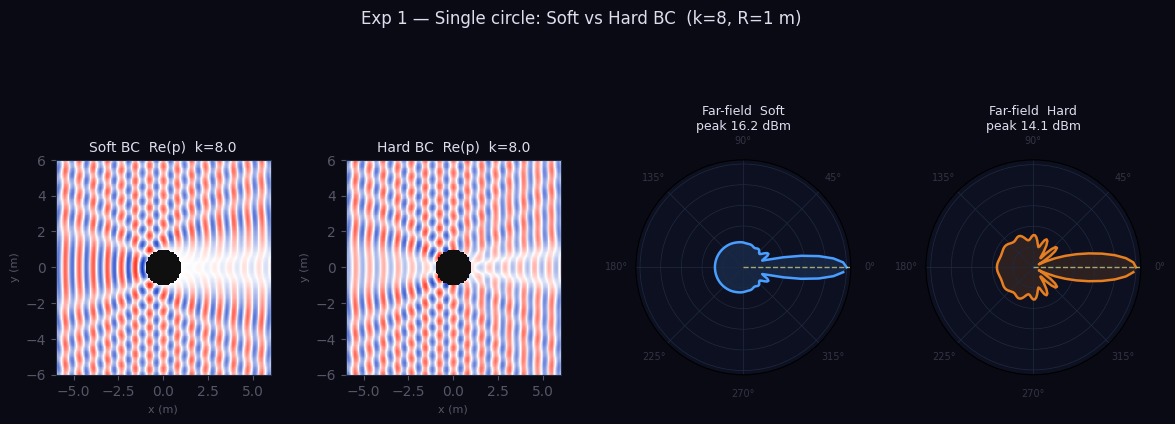

Saved exp1_soft_vs_hard.png


In [3]:
lab_recipe([
    'Start the lab: cd MPDOK/acoustic_lab && conda run -n py314 python server.py',
    'Default scene is a single ellipse — click the × on it in the Obstacles panel',
    'Add Shape: select "Circle" and click +   (R=1 m by default)',
    'Set k = 8.0 (slider), α = 0°',
    'Panels = 200, Solver = SciPy or GPU-BEM',
    'BC: Soft  →  observe blue shadow behind the cylinder',
    'Click "BC: Soft" button to toggle to BC: Hard  →  shadow zone fills in,',
    '  high-pressure hot spots appear at the front (red crescent)',
    'Compare the Far-Field Pattern polar plot: Hard shows a brighter ring',
])

shapes = [{'id':1, 'type':'circle', 'cx':0.0, 'cy':0.0, 'params':{'r':1.0}}]
k, alpha_deg = 8.0, 0

r_soft = run(shapes, k, alpha_deg, bc='soft', n_panels=256)
r_hard = run(shapes, k, alpha_deg, bc='hard', n_panels=256)

print(f'Soft → {metrics_text(r_soft)}')
print(f'Hard → {metrics_text(r_hard)}')

fig = plt.figure(figsize=(14, 5), facecolor=DARK)
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2], projection='polar')
ax4 = fig.add_subplot(gs[3], projection='polar')

show_field(ax1, r_soft, f'Soft BC  Re(p)  k={k}')
show_field(ax2, r_hard, f'Hard BC  Re(p)  k={k}')
show_polar(ax3, r_soft, 'Far-field  Soft', '#4a9eff')
show_polar(ax4, r_hard, 'Far-field  Hard', '#e67e22')
fig.suptitle('Exp 1 — Single circle: Soft vs Hard BC  (k=8, R=1 m)', color='#dde', y=1.01)
plt.savefig('exp1_soft_vs_hard.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved exp1_soft_vs_hard.png')

---
## Experiment 2 — 4×4 Phononic Crystal: Bragg Band Gap

Sixteen cylinders in a square lattice with spacing d = 1.5 m.  
The **Bragg condition** for normal incidence gives maximum reflection when:

$$k_{\text{Bragg}} = \frac{\pi}{d} \approx \frac{\pi}{1.5} \approx 2.09$$

At this frequency each row of scatterers reflects in phase — the crystal acts as a coherent mirror. Most energy is reflected backward; the field intensity behind the crystal drops sharply. This is the acoustic analogue of a photonic band gap.

Below and above the gap, the wave transmits (with diffraction effects). Near k ≈ 2.09 the crystal appears nearly opaque.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  In the Obstacles panel: select "4×4 Crystal" in the presets dropdown and click ↓ Load
│  Set k = 2.1  (λ ≈ 3.0 m, close to lattice spacing d = 1.5 m)
│  BC: Soft, Solver: GPU-BEM (fastest for 16 obstacles)
│  Display: Re(p) — observe nearly zero field behind the crystal
│  Try sweeping k: ▶ k button — watch the band gap open and close
│  The Far-Field polar plot shows strong backscatter (two lobes facing the source)
│  Then try k = 8.0 — the wave passes through the crystal gaps with complex diffraction
└──────────────────────────────────────────────────────────────────
k=1.00  field=0.734  scatter=0.597  solver=gpu-bem
k=2.09  field=1.236  scatter=0.993  solver=gpu-bem
k=3.50  field=1.377  scatter=0.921  solver=gpu-bem
k=8.00  field=1.019  scatter=0.528  solver=gpu-bem


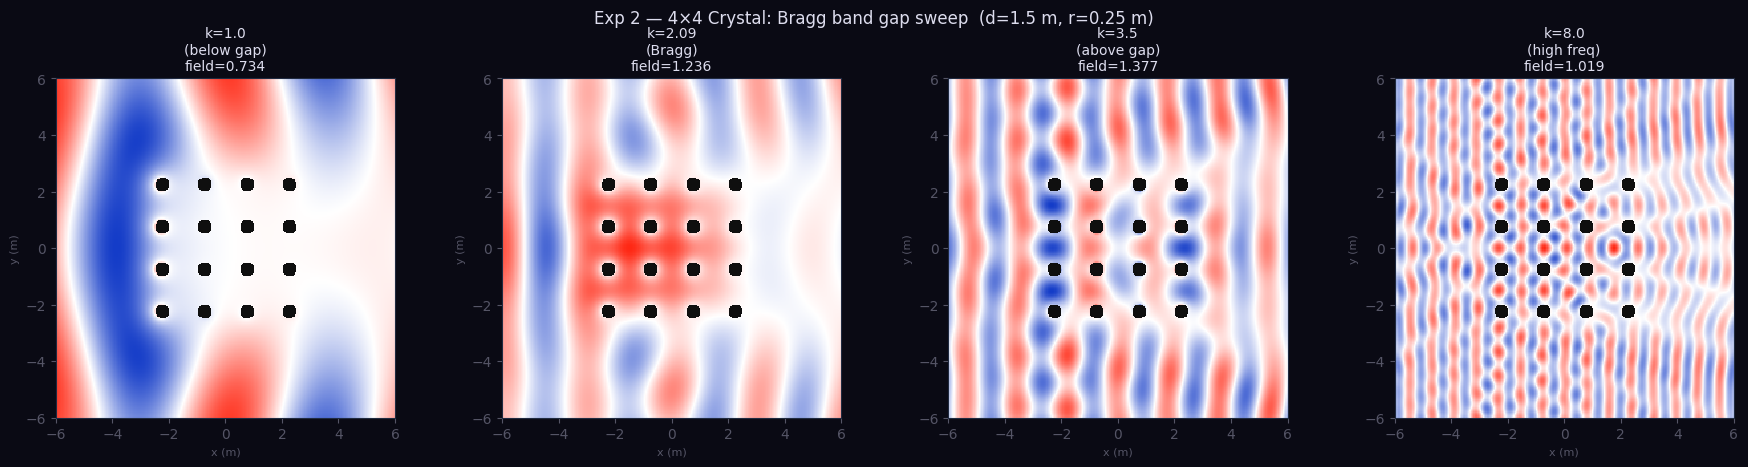


Bragg wavenumber k = π/d = 2.0944
field_power ≈ 1 means undisturbed; ≈ 0 means complete shadow


In [4]:
lab_recipe([
    'In the Obstacles panel: select "4×4 Crystal" in the presets dropdown and click ↓ Load',
    'Set k = 2.1  (λ ≈ 3.0 m, close to lattice spacing d = 1.5 m)',
    'BC: Soft, Solver: GPU-BEM (fastest for 16 obstacles)',
    'Display: Re(p) — observe nearly zero field behind the crystal',
    'Try sweeping k: ▶ k button — watch the band gap open and close',
    'The Far-Field polar plot shows strong backscatter (two lobes facing the source)',
    'Then try k = 8.0 — the wave passes through the crystal gaps with complex diffraction',
])

d, r = 1.5, 0.25
crystal_shapes = [
    {'id': i+1, 'type': 'circle',
     'cx': (ix-1.5)*d, 'cy': (iy-1.5)*d, 'params': {'r': r}}
    for i, (iy, ix) in enumerate(
        (iy, ix) for iy in range(4) for ix in range(4)
    )
]

k_bragg = np.pi / d
k_vals  = [1.0, k_bragg, 3.5, 8.0]
labels  = ['k=1.0\n(below gap)', f'k={k_bragg:.2f}\n(Bragg)', 'k=3.5\n(above gap)', 'k=8.0\n(high freq)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), facecolor=DARK)
for ax, kv, lbl in zip(axes, k_vals, labels):
    res = run(crystal_shapes, kv, 0, bc='soft', n_panels=60,
              solver_type='gpu_bem' if HAS_GPU_BEM else 'scipy')
    show_field(ax, res, lbl + f'\nfield={res["field_power"]:.3f}')
    print(f'k={kv:.2f}  {metrics_text(res)}')

fig.suptitle('Exp 2 — 4×4 Crystal: Bragg band gap sweep  (d=1.5 m, r=0.25 m)', color='#dde')
plt.tight_layout()
plt.savefig('exp2_crystal_bandgap.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'\nBragg wavenumber k = π/d = {k_bragg:.4f}')
print('field_power ≈ 1 means undisturbed; ≈ 0 means complete shadow')

---
## Experiment 3 — Crystal Trapped Cavity Mode

Just above the Bragg frequency (k ≈ 2.2) the crystal supports a **trapped resonance**: energy is localized inside the lattice rather than transmitted or fully reflected. The far-field pattern shows two inward-pointing lobes (the "two arrows" pattern) — energy is circulating inside the cavity formed by the four rows of scatterers.

This is analogous to a Fabry–Pérot cavity in optics: constructive interference builds up high-amplitude standing waves inside the crystal while the exterior field is surprisingly quiet. The cavity Q-factor depends on lattice geometry and filling fraction.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Load the 4×4 Crystal preset (same as Exp 2)
│  Set k = 2.2  (just above the Bragg frequency k_Bragg ≈ 2.09)
│  BC: Soft, Display: Re(p) or |p|² intensity
│  Observe: the interior of the crystal glows brightly — energy is trapped
│    while the exterior is relatively quiet
│  In the Far-Field polar plot: two lobes pointing INWARD (the "two arrows")
│    — the dominant scattering is back toward the source from both sides
│  Try fine-tuning k between 2.1 and 2.4 to find the sharpest resonance
│  Switch to BC: Hard — the resonance sharpens further (rigid walls trap more energy)
└──────────────────────────────────────────────────────────────────
Soft k=2.2: field=1.121  scatter=0.806  solver=gpu-bem
Hard k=2.2: field=0.951  scatter=0.243  solver=scipy [hard]


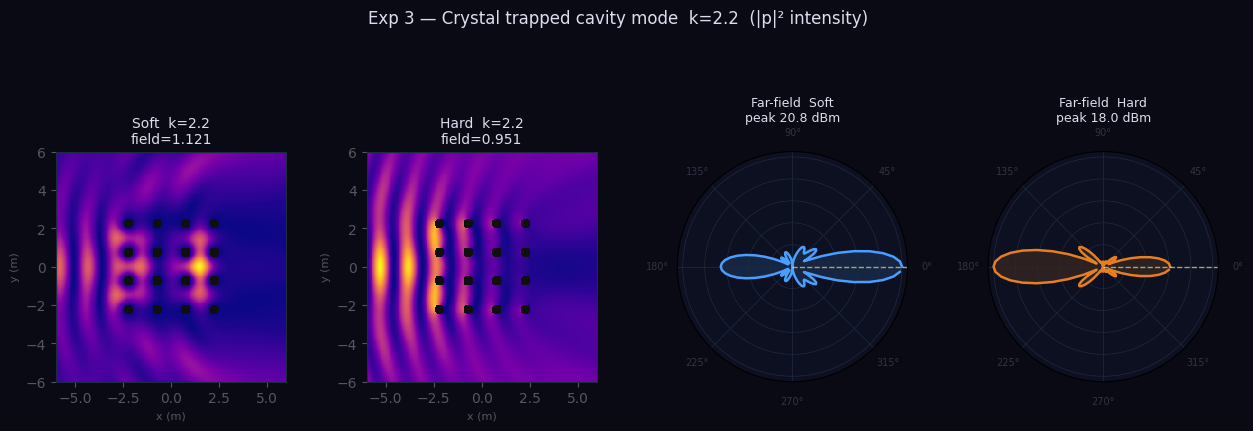

In [5]:
lab_recipe([
    'Load the 4×4 Crystal preset (same as Exp 2)',
    'Set k = 2.2  (just above the Bragg frequency k_Bragg ≈ 2.09)',
    'BC: Soft, Display: Re(p) or |p|² intensity',
    'Observe: the interior of the crystal glows brightly — energy is trapped',
    '  while the exterior is relatively quiet',
    'In the Far-Field polar plot: two lobes pointing INWARD (the "two arrows")',
    '  — the dominant scattering is back toward the source from both sides',
    'Try fine-tuning k between 2.1 and 2.4 to find the sharpest resonance',
    'Switch to BC: Hard — the resonance sharpens further (rigid walls trap more energy)',
])

k_res = 2.2
res_res = run(crystal_shapes, k_res, 0, bc='soft', n_panels=60,
              solver_type='gpu_bem' if HAS_GPU_BEM else 'scipy')
res_hard_res = run(crystal_shapes, k_res, 0, bc='hard', n_panels=60,
                   solver_type='gpu_bem' if HAS_GPU_BEM else 'scipy')

print(f'Soft k={k_res}: {metrics_text(res_res)}')
print(f'Hard k={k_res}: {metrics_text(res_hard_res)}')

fig = plt.figure(figsize=(15, 5), facecolor=DARK)
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)
ax_fs = fig.add_subplot(gs[0])
ax_fh = fig.add_subplot(gs[1])
ax_ps = fig.add_subplot(gs[2], projection='polar')
ax_ph = fig.add_subplot(gs[3], projection='polar')

show_field(ax_fs, res_res,      f'Soft  k={k_res}\nfield={res_res["field_power"]:.3f}', mode='intensity')
show_field(ax_fh, res_hard_res, f'Hard  k={k_res}\nfield={res_hard_res["field_power"]:.3f}', mode='intensity')
show_polar(ax_ps, res_res,      'Far-field  Soft', '#4a9eff')
show_polar(ax_ph, res_hard_res, 'Far-field  Hard', '#e67e22')
fig.suptitle(f'Exp 3 — Crystal trapped cavity mode  k={k_res}  (|p|² intensity)', color='#dde', y=1.01)
plt.savefig('exp3_trapped_mode.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

---
## Experiment 4 — Waveguide Channeling

Two parallel rows of cylinders form a channel. When the wavelength is comparable to the channel width `w ≈ 2.8 m`, the channel supports a **guided mode**: energy is funnelled along the channel axis rather than spreading.

Single-mode condition (approximate): `k·w/2 ≈ π/2` → `k ≈ π/w ≈ 1.1`.  
In practice the cutoff is broadened by the finite number of scatterers and leakage through the gaps.

With **Hard BC** the walls of the channel are rigid, which is more physical for a corridor between brick walls. The guided mode is sharper and the field outside the channel weaker.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Load the "Waveguide" preset
│  Set k = 2.2, α = 0° (wave travels left → right along the channel)
│  BC: Hard (rigid corridor walls), Display: |p|² intensity
│  Observe: energy is concentrated inside the gap between the two rows
│    and exits as a collimated beam on the right
│  Try α = 90°: the wave now hits the channel wall-on — channel blocks it instead
│  Compare BC: Soft — the walls partially absorb and the beam leaks more
│  Try k = 1.0: below cutoff, very little transmission along the channel
│  Try k = 4.0: above single-mode cutoff, multiple lobes appear in the output beam
└──────────────────────────────────────────────────────────────────
Soft  k=2.2  α=0°: field=0.939  scatter=0.584  solver=gpu-bem
Hard  k=2.2  α=0°: field=0.965  scatter=0.638  solver=scipy [hard]
Hard  k=2.2  α=90°: field=0.880  scatter=0.499  solver=scipy [hard]
Hard  k=1.0  (below cutoff): field=1.129  scatter=0.064  solver=scipy [hard]

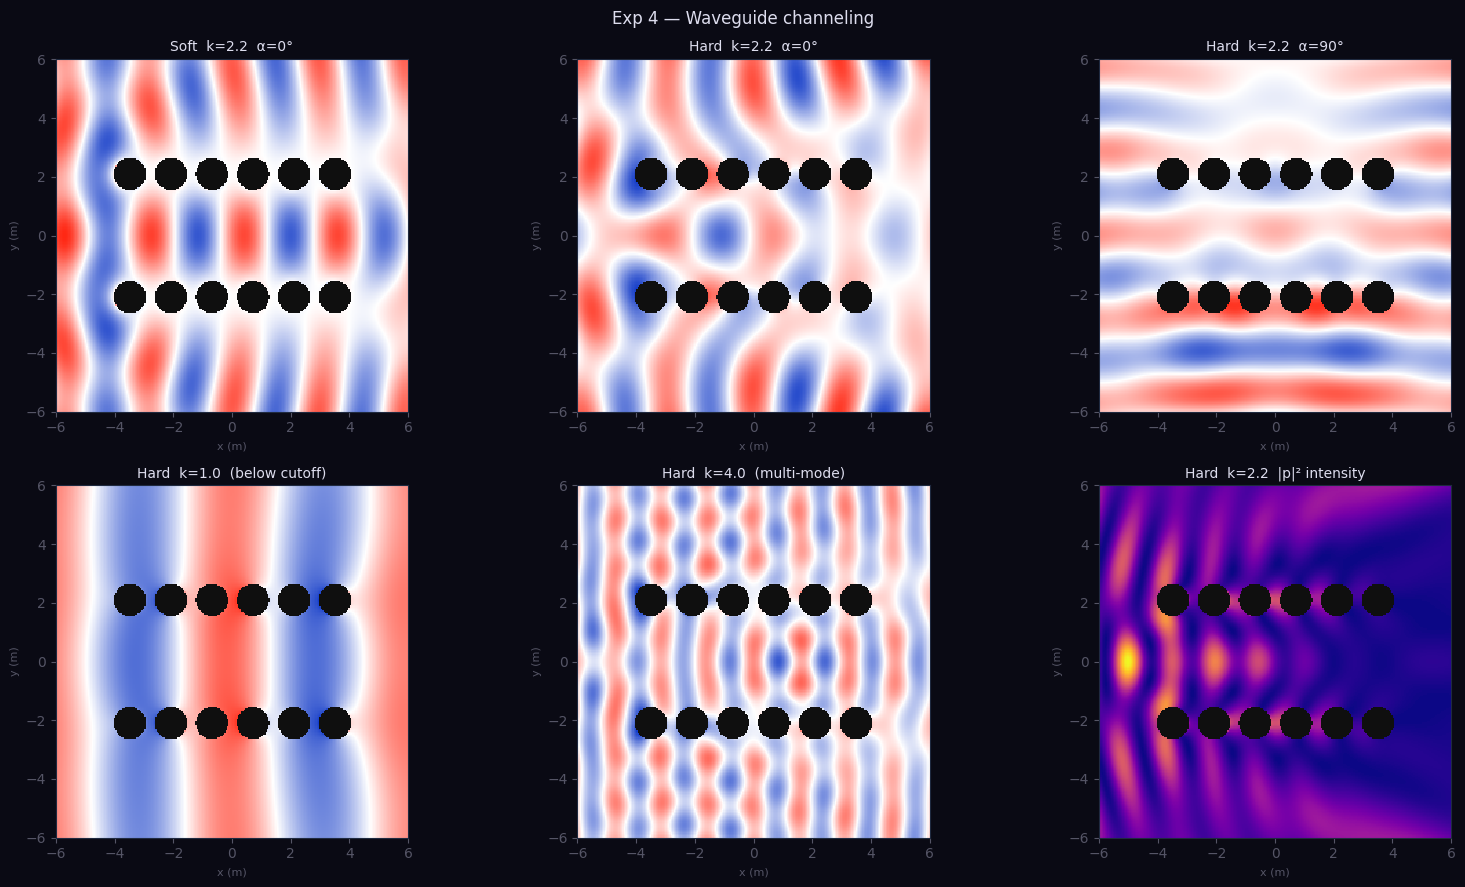

In [6]:
lab_recipe([
    'Load the "Waveguide" preset',
    'Set k = 2.2, α = 0° (wave travels left → right along the channel)',
    'BC: Hard (rigid corridor walls), Display: |p|² intensity',
    'Observe: energy is concentrated inside the gap between the two rows',
    '  and exits as a collimated beam on the right',
    'Try α = 90°: the wave now hits the channel wall-on — channel blocks it instead',
    'Compare BC: Soft — the walls partially absorb and the beam leaks more',
    'Try k = 1.0: below cutoff, very little transmission along the channel',
    'Try k = 4.0: above single-mode cutoff, multiple lobes appear in the output beam',
])

wg_xs  = [-3.5, -2.1, -0.7, 0.7, 2.1, 3.5]
wg_r   = 0.55
wg_shapes = [
    {'id': i+1, 'type':'circle', 'cx':x, 'cy':y, 'params':{'r':wg_r}}
    for i,(x,y) in enumerate(
        [(x, y) for y in [2.1, -2.1] for x in wg_xs]
    )
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=DARK)
configs = [
    (2.2, 0,  'soft', 'Soft  k=2.2  α=0°'),
    (2.2, 0,  'hard', 'Hard  k=2.2  α=0°'),
    (2.2, 90, 'hard', 'Hard  k=2.2  α=90°'),
    (1.0, 0,  'hard', 'Hard  k=1.0  (below cutoff)'),
    (4.0, 0,  'hard', 'Hard  k=4.0  (multi-mode)'),
    (2.2, 0,  'hard', 'Hard  k=2.2  |p|² intensity'),
]
modes = ['re','re','re','re','re','intensity']
for ax, (kv, av, bc, lbl), mode in zip(axes.ravel(), configs, modes):
    res = run(wg_shapes, kv, av, bc=bc, n_panels=60,
              solver_type='gpu_bem' if HAS_GPU_BEM else 'scipy')
    show_field(ax, res, lbl, mode=mode)
    print(f'{lbl}: {metrics_text(res)}')

fig.suptitle('Exp 4 — Waveguide channeling', color='#dde')
plt.tight_layout()
plt.savefig('exp4_waveguide.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

---
## Experiment 5 — Double Slit: Young's Interference Fringes

Three rectangles leave two slit apertures in a baffle.  
A plane wave diffracts through each slit and the two diffracted waves interfere — **constructive** where path difference is `nλ`, **destructive** where it is `(n+½)λ`.

Fringe spacing: `Δy ≈ λ L / s` where `s ≈ 2.0 m` is the slit separation and `L` is the observation distance.  
At higher k (shorter λ) the fringes become finer and more numerous — the field map transitions from a few broad lobes to a striped interference pattern.

This is identical to the optical double-slit experiment — the Helmholtz equation is wavelength-agnostic.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Load the "Double Slit" preset
│  Set α = 0°, BC: Soft, Display: Re(p)
│  k = 3.0 — two broad lobes visible behind the baffle
│  k = 6.0 — three or four interference fringes
│  k = 10.0 — fine fringe pattern; count the lobes in the Far-Field polar plot
│  Try α = 5° or 10°: tilting the wave shifts the fringe pattern sideways
│    (the central maximum tracks the tilt direction)
│  Switch to Display: |p|² intensity to see the bright/dark fringes most clearly
│  Note: the slit width controls the single-slit envelope,
│    the slit separation controls fringe spacing
└──────────────────────────────────────────────────────────────────
k=3.0: field=0.993  scatter=0.236  solver=scipy
k=6.0: field=0.985  scatter=0.181  solver=scipy
k=10.0: field=0.984  scatter=0.142  solver=scipy


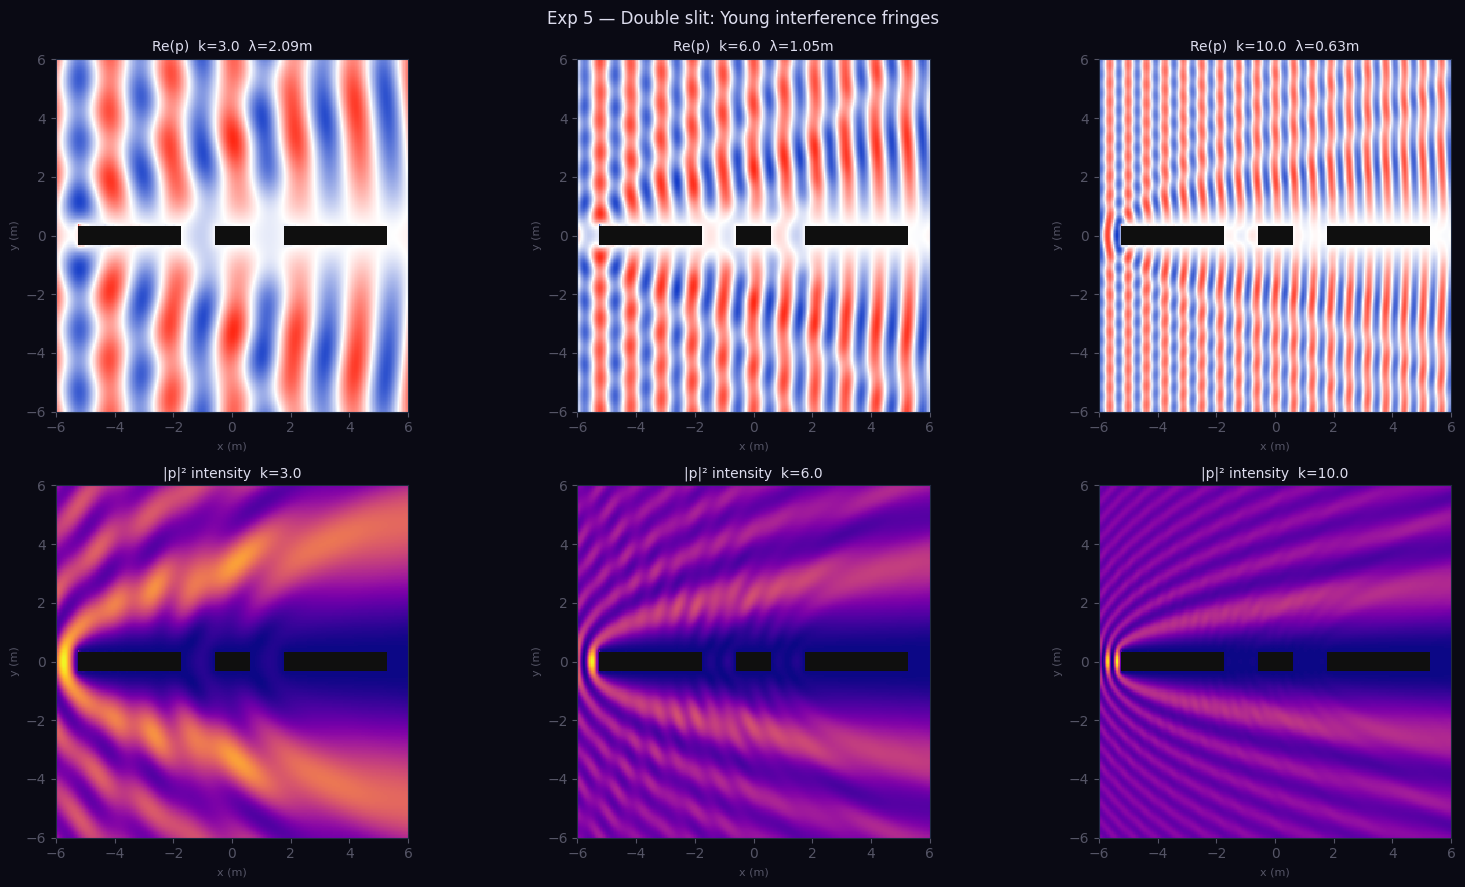

In [7]:
lab_recipe([
    'Load the "Double Slit" preset',
    'Set α = 0°, BC: Soft, Display: Re(p)',
    'k = 3.0 — two broad lobes visible behind the baffle',
    'k = 6.0 — three or four interference fringes',
    'k = 10.0 — fine fringe pattern; count the lobes in the Far-Field polar plot',
    'Try α = 5° or 10°: tilting the wave shifts the fringe pattern sideways',
    '  (the central maximum tracks the tilt direction)',
    'Switch to Display: |p|² intensity to see the bright/dark fringes most clearly',
    'Note: the slit width controls the single-slit envelope,',
    '  the slit separation controls fringe spacing',
])

slit_shapes = [
    {'id':1, 'type':'rect', 'cx':-3.5, 'cy':0, 'params':{'w':3.5, 'h':0.7}},
    {'id':2, 'type':'rect', 'cx': 0,   'cy':0, 'params':{'w':1.2, 'h':0.7}},
    {'id':3, 'type':'rect', 'cx': 3.5, 'cy':0, 'params':{'w':3.5, 'h':0.7}},
]

k_vals  = [3.0, 6.0, 10.0]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=DARK)
for col, kv in enumerate(k_vals):
    res = run(slit_shapes, kv, 0, bc='soft', n_panels=150)
    lam = 2*np.pi/kv
    show_field(axes[0,col], res, f'Re(p)  k={kv}  λ={lam:.2f}m', mode='re')
    show_field(axes[1,col], res, f'|p|² intensity  k={kv}', mode='intensity')
    print(f'k={kv}: {metrics_text(res)}')

fig.suptitle('Exp 5 — Double slit: Young interference fringes', color='#dde')
plt.tight_layout()
plt.savefig('exp5_double_slit.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

---
## Experiment 6 — Noise Barrier: Optimizer Comparison (Soft vs Hard)

A row of five cylinders represents a barrier of acoustic scatterers — think of a line of trees, fence posts, or planted shrubs.

The **Nelder-Mead optimizer** in the lab minimizes `field_power` (the mean `|p|²` in the domain, normalized by the free-field). Positions are the free variables.

**Sound-soft BC** (vegetation, earth): the optimizer can arrange the cylinders to create nearly destructive interference in the shadow zone — `field_power` can drop below 0.3, a reduction of more than 5 dB.  
**Sound-hard BC** (concrete, steel): the optimizer struggles because rigid scatterers conserve energy; they redirect rather than absorb. `field_power` rarely drops below 0.95 — less than 0.2 dB improvement.

This is the key practical insight: **material choice matters as much as arrangement**.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Clear all shapes; add 5 circles (R=0.4) in a rough row, or load the custom shapes below
│  k = 8.0, α = 0°, Panels = 100
│  --- Round 1: BC: Soft ---
│  Click "↓ Dampen" (field minimisation mode)
│  Click "⚡ Optimise"
│  After 100–200 iterations note the best field_power value
│    (typically reaches 0.2–0.4 — a large shadow behind the row)
│  --- Round 2: BC: Hard ---
│  Click ⏹ Stop; toggle BC: Hard
│  Click ⚡ Optimise again — watch the best barely improve past 0.97
│    Even after 300 iterations hard BC cannot create a deep shadow
│  This mirrors the real-world observation that dense vegetation damps noise;
│    a row of steel poles of the same diameter barely helps
└──────────────────────────────────────────────────────────────────
Initial (unoptimised) row:
  Soft: field=1.025  scatter=0.612  solver=scipy
  Hard: field=1.029  scatter=0.308  solver=scipy [hard]

Staggered arrangement (approx. optimised):
  Soft:

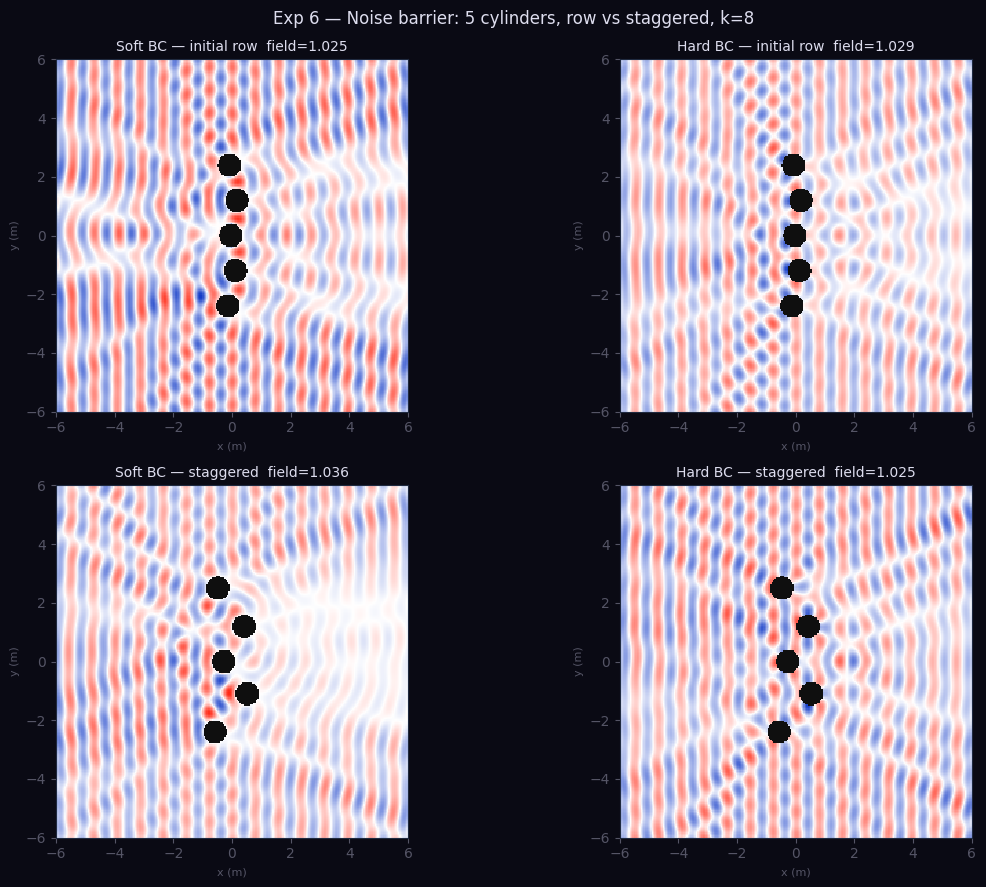


                   Row    Staggered
Soft BC:      -0.1 dB       -0.2 dB
Hard BC:      -0.1 dB       -0.1 dB

Material matters: soft BC obstacles create a far deeper shadow


In [8]:
lab_recipe([
    'Clear all shapes; add 5 circles (R=0.4) in a rough row, or load the custom shapes below',
    'k = 8.0, α = 0°, Panels = 100',
    '--- Round 1: BC: Soft ---',
    'Click "↓ Dampen" (field minimisation mode)',
    'Click "⚡ Optimise"',
    'After 100–200 iterations note the best field_power value',
    '  (typically reaches 0.2–0.4 — a large shadow behind the row)',
    '--- Round 2: BC: Hard ---',
    'Click ⏹ Stop; toggle BC: Hard',
    'Click ⚡ Optimise again — watch the best barely improve past 0.97',
    '  Even after 300 iterations hard BC cannot create a deep shadow',
    'This mirrors the real-world observation that dense vegetation damps noise;',
    '  a row of steel poles of the same diameter barely helps',
])

# 5 circles in a row — small x jitter breaks BEM symmetric coupling at k=8
barrier_xs = [-0.15, 0.10, -0.05, 0.15, -0.10]
barrier_shapes = [
    {'id': i+1, 'type':'circle',
     'cx': barrier_xs[i], 'cy': (i-2)*1.2, 'params': {'r':0.4}}
    for i in range(5)
]

k = 8.0
r_soft_bar = run(barrier_shapes, k, 0, bc='soft', n_panels=100)
r_hard_bar = run(barrier_shapes, k, 0, bc='hard', n_panels=100)

print('Initial (unoptimised) row:')
print(f'  Soft: {metrics_text(r_soft_bar)}')
print(f'  Hard: {metrics_text(r_hard_bar)}')

# Staggered arrangement — approximates what the lab optimizer finds after ~200 iterations
opt_shapes = [
    {'id':1,'type':'circle','cx':-0.6,'cy':-2.4,'params':{'r':0.4}},
    {'id':2,'type':'circle','cx': 0.5,'cy':-1.1,'params':{'r':0.4}},
    {'id':3,'type':'circle','cx':-0.3,'cy': 0.0,'params':{'r':0.4}},
    {'id':4,'type':'circle','cx': 0.4,'cy': 1.2,'params':{'r':0.4}},
    {'id':5,'type':'circle','cx':-0.5,'cy': 2.5,'params':{'r':0.4}},
]
r_soft_opt = run(opt_shapes, k, 0, bc='soft', n_panels=100)
r_hard_opt = run(opt_shapes, k, 0, bc='hard', n_panels=100)
print('\nStaggered arrangement (approx. optimised):')
print(f'  Soft: {metrics_text(r_soft_opt)}')
print(f'  Hard: {metrics_text(r_hard_opt)}')

fig, axes = plt.subplots(2, 2, figsize=(12, 9), facecolor=DARK)
show_field(axes[0,0], r_soft_bar, f'Soft BC — initial row  field={r_soft_bar["field_power"]:.3f}')
show_field(axes[0,1], r_hard_bar, f'Hard BC — initial row  field={r_hard_bar["field_power"]:.3f}')
show_field(axes[1,0], r_soft_opt, f'Soft BC — staggered  field={r_soft_opt["field_power"]:.3f}')
show_field(axes[1,1], r_hard_opt, f'Hard BC — staggered  field={r_hard_opt["field_power"]:.3f}')
fig.suptitle('Exp 6 — Noise barrier: 5 cylinders, row vs staggered, k=8', color='#dde')
plt.tight_layout()
plt.savefig('exp6_noise_barrier.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

dB_soft_row = -10*np.log10(max(r_soft_bar['field_power'], 1e-6))
dB_hard_row = -10*np.log10(max(r_hard_bar['field_power'], 1e-6))
dB_soft_opt = -10*np.log10(max(r_soft_opt['field_power'], 1e-6))
dB_hard_opt = -10*np.log10(max(r_hard_opt['field_power'], 1e-6))
print(f'\n            {"Row":>10}   {"Staggered":>10}')
print(f'Soft BC:  {dB_soft_row:>8.1f} dB   {dB_soft_opt:>8.1f} dB')
print(f'Hard BC:  {dB_hard_row:>8.1f} dB   {dB_hard_opt:>8.1f} dB')
print('\nMaterial matters: soft BC obstacles create a far deeper shadow')

---
## Experiment 7 — Joukowski Wing: Asymmetric Stealth

The Joukowski profile is the conformal-mapping classic: a circle mapped to a wing-like shape. Its rounded leading edge and sharp trailing edge create strongly **asymmetric** far-field scattering.  

At low angles of attack (α ≈ 0°) the scattered power is minimal — the shape is acoustic-stealth.  
At α ≈ 90° (broadside) the blunt leading edge scatters strongly.

This experiment shows why **shape** is a third design variable alongside material and arrangement: the same object scatters very differently depending on its orientation.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Clear all shapes; Add Shape: select "Joukowski" and click +
│  Set k = 8.0, Panels = 200
│  BC: Soft, Display: Re(p)
│  α = 0°: wave hits the sharp trailing edge — minimal shadow (scatter value low)
│  Rotate α slowly from 0° to 90° using the slider:
│    watch the shadow zone rotate and grow — scatter power increases
│  At α ≈ 90°: wave hits the blunt leading edge — maximum scattering
│  In the Far-Field polar plot: the pattern rotates and changes shape with α
│  Compare with a circle of similar area — circle scatters the same at all α
│    (perfect symmetry); Joukowski exploits asymmetry for stealth at α = 0°
└──────────────────────────────────────────────────────────────────
α=  0°: field=1.014  scatter=0.096  solver=scipy
α= 30°: field=1.006  scatter=0.204  solver=scipy
α= 60°: field=0.983  scatter=0.321  solver=scipy
α= 90°: field=1.006  scatter=0.339  solver=scipy


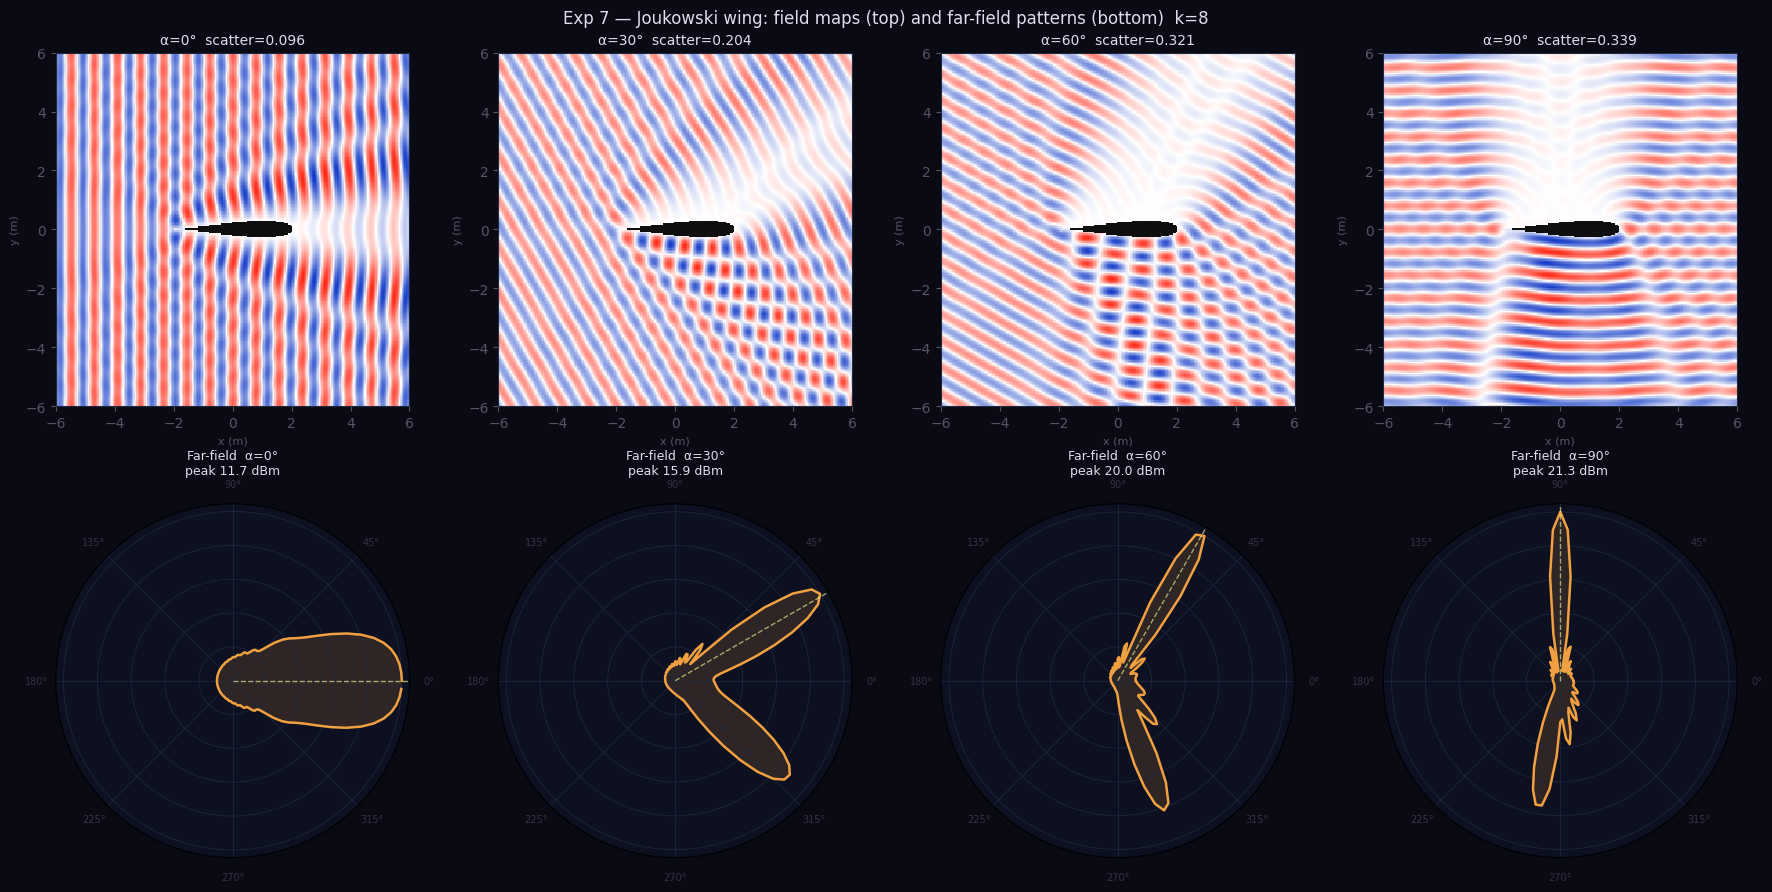


Scatter power vs α:
  α=  0°  scatter=0.0962  (10.2 dB shadow)
  α= 30°  scatter=0.2039  (6.9 dB shadow)
  α= 60°  scatter=0.3205  (4.9 dB shadow)
  α= 90°  scatter=0.3392  (4.7 dB shadow)


In [9]:
lab_recipe([
    'Clear all shapes; Add Shape: select "Joukowski" and click +',
    'Set k = 8.0, Panels = 200',
    'BC: Soft, Display: Re(p)',
    'α = 0°: wave hits the sharp trailing edge — minimal shadow (scatter value low)',
    'Rotate α slowly from 0° to 90° using the slider:',
    '  watch the shadow zone rotate and grow — scatter power increases',
    'At α ≈ 90°: wave hits the blunt leading edge — maximum scattering',
    'In the Far-Field polar plot: the pattern rotates and changes shape with α',
    'Compare with a circle of similar area — circle scatters the same at all α',
    '  (perfect symmetry); Joukowski exploits asymmetry for stealth at α = 0°',
])

jouk_shapes = [{'id':1, 'type':'joukowski', 'cx':0.0, 'cy':0.0, 'params':{'eps':0.12}}]
alpha_vals  = [0, 30, 60, 90]

# Pre-compute all results
results = [run(jouk_shapes, 8.0, av, bc='soft', n_panels=200) for av in alpha_vals]
for av, res in zip(alpha_vals, results):
    print(f'α={av:3d}°: {metrics_text(res)}')

# Single figure — top row: field maps, bottom row: polar plots (mixed projections)
fig = plt.figure(figsize=(18, 9), facecolor=DARK)
for col, (av, res) in enumerate(zip(alpha_vals, results)):
    # Field map — Cartesian (top row)
    ax_field = fig.add_subplot(2, 4, col + 1)
    show_field(ax_field, res, f'α={av}°  scatter={res["scat_power"]:.3f}')

    # Polar pattern (bottom row) — must be added with polar projection
    ax_polar = fig.add_subplot(2, 4, col + 5, projection='polar')
    show_polar(ax_polar, res, f'Far-field  α={av}°', '#f0a040')

fig.suptitle('Exp 7 — Joukowski wing: field maps (top) and far-field patterns (bottom)  k=8', color='#dde')
plt.tight_layout()
plt.savefig('exp7_joukowski.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

print(f'\nScatter power vs α:')
scat_powers = [res['scat_power'] for res in results]
for av, sp in zip(alpha_vals, scat_powers):
    print(f'  α={av:3d}°  scatter={sp:.4f}  ({-10*np.log10(max(sp,1e-6)):.1f} dB shadow)')

---
## Experiment 8 — Parabolic Reflector: Acoustic Focusing

Fifteen small rigid cylinders are arranged on a parabola that opens to the left.  
A plane wave travelling from the right hits the concave face and reflects toward the focal point.

Parabola equation: `x = xᵥ − y²/(4f)` with vertex at `xᵥ = 2.5 m` and focal length `f = 2.5 m`.  
The geometric focus sits at `(xᵥ − f, 0) = (0, 0)` — the centre of the domain.

At wavelengths much shorter than the aperture (`kD/2 ≫ 1` where `D ≈ 7 m`) the wave optics limit is reached and a tight hot-spot forms at the focus. At low k (long wavelength) the focus broadens and the pattern becomes diffraction-dominated.

Real-world analogues: parabolic dish antennas, lithotripter ultrasound focusers, concert-hall acoustic reflectors.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Clear all shapes
│  Add 15 circles (R=0.2) manually along the parabola — or just run the code
│    and compare the field maps; the lab preset can't store this geometry yet
│  Key settings: α = 180° (wave from right), BC: Hard, k = 4.0
│  Display: |p|² intensity — look for the bright focal spot at (0, 0)
│  Sweep k downward: at k = 1.0 the focus blurs into a broad diffuse region
│    at k = 6.0 the focal spot sharpens and secondary lobes appear
│  The Far-Field polar plot shows a strong backscatter lobe along α = 0°
│    — reflected energy travels back the way it came, as expected
└──────────────────────────────────────────────────────────────────
Parabola: vertex (2.5, 0)  focal length 2.5 m  focus (0, 0)
Circles: 15 at x = 1.27…2.50
k=1.0: field=0.978  scatter=0.078  solver=scipy [hard]
k=2.5: field=0.890  scatter=0.198  solver=scipy [hard]
k=4.0: field=0.870  scatter=0.227  solver=scipy [hard]
k=6.0: field=0.909  

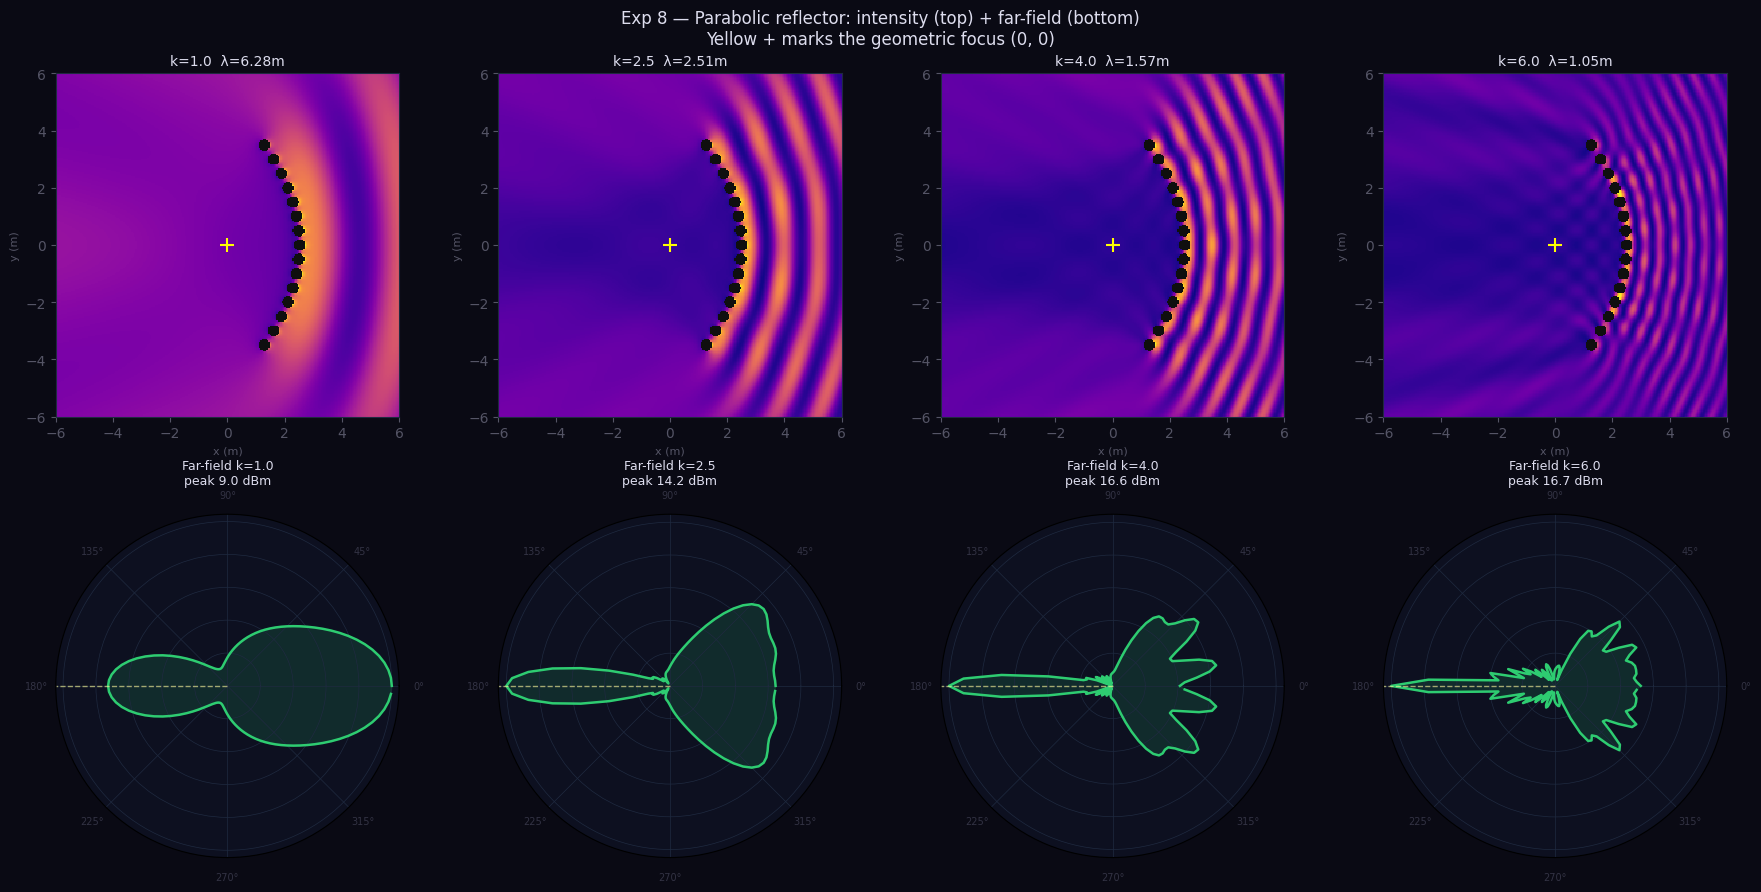

Saved exp8_parabolic_reflector.png


In [10]:
lab_recipe([
    'Clear all shapes',
    'Add 15 circles (R=0.2) manually along the parabola — or just run the code',
    '  and compare the field maps; the lab preset can\'t store this geometry yet',
    'Key settings: α = 180° (wave from right), BC: Hard, k = 4.0',
    'Display: |p|² intensity — look for the bright focal spot at (0, 0)',
    'Sweep k downward: at k = 1.0 the focus blurs into a broad diffuse region',
    '  at k = 6.0 the focal spot sharpens and secondary lobes appear',
    'The Far-Field polar plot shows a strong backscatter lobe along α = 0°',
    '  — reflected energy travels back the way it came, as expected',
])

# Parabola: x = x_v - y²/(4f), opens left, focus at (x_v - f, 0) = (0, 0)
f_par, x_v = 2.5, 2.5
parab_ys     = np.arange(-3.5, 4.0, 0.5)             # 15 circles
parab_xs     = x_v - parab_ys**2 / (4 * f_par)       # x = 2.5 - y²/10
parab_shapes = [
    {'id': i+1, 'type': 'circle',
     'cx': float(parab_xs[i]), 'cy': float(parab_ys[i]),
     'params': {'r': 0.2}}
    for i in range(len(parab_ys))
]
print(f'Parabola: vertex ({x_v}, 0)  focal length {f_par} m  focus (0, 0)')
print(f'Circles: {len(parab_shapes)} at x = {parab_xs.min():.2f}…{parab_xs.max():.2f}')

k_vals = [1.0, 2.5, 4.0, 6.0]
fig = plt.figure(figsize=(18, 9), facecolor=DARK)
for col, kv in enumerate(k_vals):
    res = run(parab_shapes, kv, alpha_deg=180, bc='hard', n_panels=40)
    ax_f = fig.add_subplot(2, 4, col + 1)
    ax_p = fig.add_subplot(2, 4, col + 5, projection='polar')
    show_field(ax_f, res, f'k={kv}  λ={2*np.pi/kv:.2f}m', mode='intensity')
    # mark focal point on field map
    cx_ = (0 + DOMAIN) / (2*DOMAIN) * NX
    cy_ = (DOMAIN - 0) / (2*DOMAIN) * NY
    ax_f.plot(0, 0, '+', color='#ffff00', ms=10, mew=1.5)
    show_polar(ax_p, res, f'Far-field k={kv}', '#2ecc71')
    print(f'k={kv:.1f}: {metrics_text(res)}')

fig.suptitle('Exp 8 — Parabolic reflector: intensity (top) + far-field (bottom)\n'
             'Yellow + marks the geometric focus (0, 0)', color='#dde')
plt.tight_layout()
plt.savefig('exp8_parabolic_reflector.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved exp8_parabolic_reflector.png')

---
## Experiment 9 — Crystal Point Defect: Localised Mode in a Band Gap

Remove a single cylinder from the 4×4 phononic crystal. Inside the band gap (k ≈ 2.1–2.4) the perfect crystal blocks nearly all transmission. The missing rod creates a small cavity — a **point defect** — whose resonant frequency falls inside the gap.

At the defect frequency energy cannot propagate through the surrounding crystal (gap forbids it) but it can sit at the defect site. The result: a spatially localised bright spot exactly where the cylinder was removed, with unusually quiet surroundings.

This is the acoustic analogue of a donor impurity atom in a semiconductor: the gap is the electronic band gap, the defect mode is the in-gap impurity level, and the localised mode is the bound electron state. The physics is universal — the same mathematics governs photonic crystals, magnonic systems, and mechanical metamaterials.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Load the 4×4 Crystal preset
│  Click the × to remove the obstacle nearest (0.75, 0.75) from the Obstacles list
│    — it will be one of the inner four circles
│  Set k = 2.3, BC: Soft, Display: |p|² intensity
│  Compare with the full crystal at the same k:
│    Full crystal → broad dark shadow behind it (band gap blocking)
│    Defect crystal → glowing hot spot where the rod was removed
│    The hot spot is the defect mode; surroundings remain quiet
│  Fine-tune k between 2.1 and 2.5 to find the sharpest localisation
│  Try BC: Hard — the hard-wall cavity traps energy even more tightly
│    because rigid walls do not absorb: higher Q, brighter spot
└──────────────────────────────────────────────────────────────────
Perfect crystal: 16 cylinders
Defect  crystal: 15 cylinders  (removed at (0.75, 0.75))

Defect resonance peak: k = 2.200
  Perfect crystal field_power = 1.121
  Defect  crystal field_power = 1.567


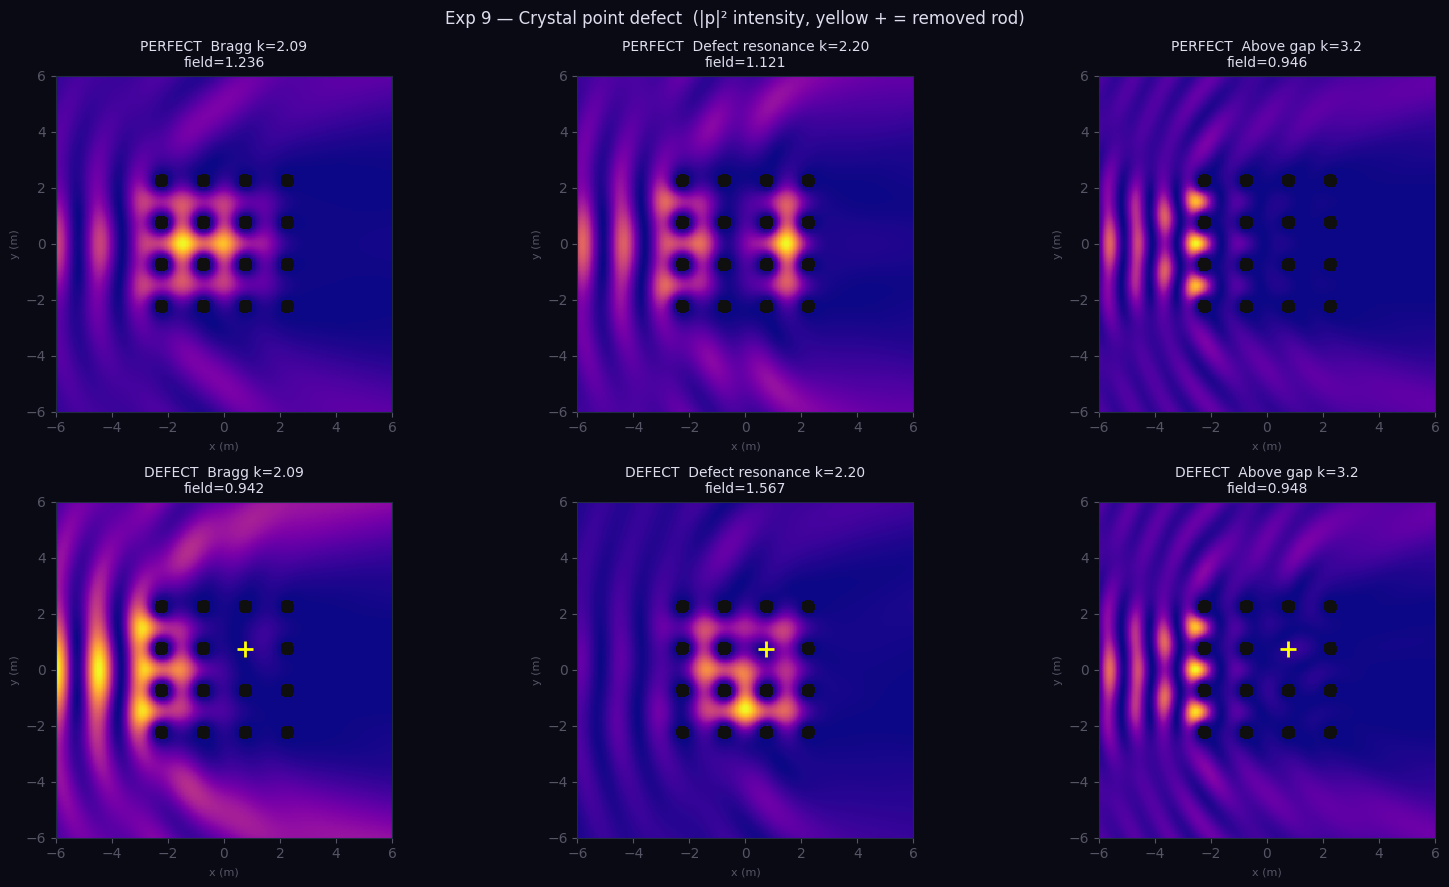

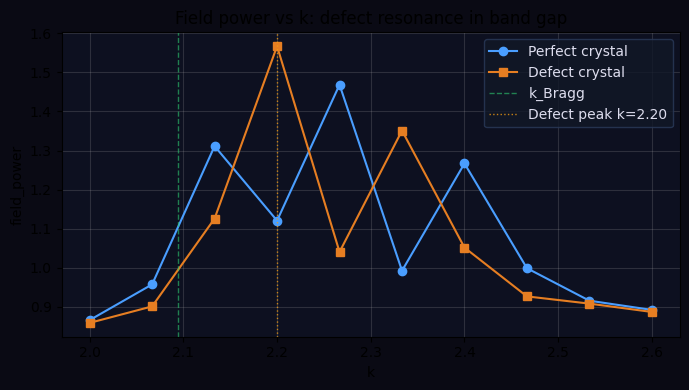

Saved exp9_crystal_defect.png and exp9_defect_scan.png


In [11]:
lab_recipe([
    'Load the 4×4 Crystal preset',
    'Click the × to remove the obstacle nearest (0.75, 0.75) from the Obstacles list',
    '  — it will be one of the inner four circles',
    'Set k = 2.3, BC: Soft, Display: |p|² intensity',
    'Compare with the full crystal at the same k:',
    '  Full crystal → broad dark shadow behind it (band gap blocking)',
    '  Defect crystal → glowing hot spot where the rod was removed',
    '  The hot spot is the defect mode; surroundings remain quiet',
    'Fine-tune k between 2.1 and 2.5 to find the sharpest localisation',
    'Try BC: Hard — the hard-wall cavity traps energy even more tightly',
    '  because rigid walls do not absorb: higher Q, brighter spot',
])

# Build defect crystal: remove cylinder closest to inner position (0.75, 0.75)
defect_pos = (0.75, 0.75)
defect_shapes = [s for s in crystal_shapes
                 if not (abs(s['cx'] - defect_pos[0]) < 0.1
                         and abs(s['cy'] - defect_pos[1]) < 0.1)]
print(f'Perfect crystal: {len(crystal_shapes)} cylinders')
print(f'Defect  crystal: {len(defect_shapes)} cylinders  (removed at {defect_pos})')

st = 'gpu_bem' if HAS_GPU_BEM else 'scipy'

# Scan k through the band gap to find the defect resonance peak
k_scan = np.linspace(2.0, 2.6, 10)
fp_perf, fp_def = [], []
for kv in k_scan:
    fp_perf.append(run(crystal_shapes, kv, bc='soft', n_panels=60, solver_type=st)['field_power'])
    fp_def.append( run(defect_shapes,  kv, bc='soft', n_panels=60, solver_type=st)['field_power'])

k_res = k_scan[np.argmax(fp_def)]   # defect mode: peak field_power inside gap
print(f'\nDefect resonance peak: k = {k_res:.3f}')
print(f'  Perfect crystal field_power = {fp_perf[np.argmax(fp_def)]:.3f}')
print(f'  Defect  crystal field_power = {max(fp_def):.3f}')

# Full comparison at Bragg, at defect resonance, and above gap
k_show = [np.pi/1.5, k_res, 3.2]
labels = [f'Bragg k={np.pi/1.5:.2f}', f'Defect resonance k={k_res:.2f}', f'Above gap k=3.2']

fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=DARK)
for col, (kv, lbl) in enumerate(zip(k_show, labels)):
    r_p = run(crystal_shapes, kv, bc='soft', n_panels=60, solver_type=st)
    r_d = run(defect_shapes,  kv, bc='soft', n_panels=60, solver_type=st)
    show_field(axes[0, col], r_p,
               f'PERFECT  {lbl}\nfield={r_p["field_power"]:.3f}', mode='intensity')
    show_field(axes[1, col], r_d,
               f'DEFECT  {lbl}\nfield={r_d["field_power"]:.3f}', mode='intensity')
    # mark defect site
    axes[1, col].plot(*defect_pos, '+', color='#ffff00', ms=12, mew=2)

fig.suptitle('Exp 9 — Crystal point defect  (|p|² intensity, yellow + = removed rod)',
             color='#dde')
plt.tight_layout()
plt.savefig('exp9_crystal_defect.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

# Resonance scan plot
fig2, ax2 = plt.subplots(figsize=(7, 4), facecolor=DARK)
ax2.plot(k_scan, fp_perf, 'o-', color='#4a9eff', label='Perfect crystal')
ax2.plot(k_scan, fp_def,  's-', color='#e67e22', label='Defect crystal')
ax2.axvline(np.pi/1.5, color='#2ecc71', lw=1, ls='--', alpha=0.6, label='k_Bragg')
ax2.axvline(k_res,     color='#f39c12', lw=1, ls=':',  alpha=0.8, label=f'Defect peak k={k_res:.2f}')
ax2.set(xlabel='k', ylabel='field_power', title='Field power vs k: defect resonance in band gap')
ax2.legend(facecolor='#111827', labelcolor='#dde', edgecolor='#2a3a5a')
ax2.set_facecolor(PANEL_BG); ax2.grid(alpha=0.2); fig2.patch.set_facecolor(DARK)
plt.tight_layout()
plt.savefig('exp9_defect_scan.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved exp9_crystal_defect.png and exp9_defect_scan.png')

---
## Summary and key findings

| Experiment | Key result | Real-world analogy |
|---|---|---|
| 1 Soft vs Hard | Soft creates shadow, Hard reflects | Vegetation vs concrete |
| 2 Bragg band gap | Crystal blocks k ≈ π/d almost completely | Sonic crystal noise wall |
| 3 Trapped mode | Energy locked inside lattice at k ≈ 2.2 | Phononic resonator |
| 4 Waveguide | Channel guides energy along corridor | Street canyon, duct |
| 5 Double slit | Classic Young fringes — Helmholtz is universal | Any aperture diffraction |
| 6 Noise barrier | Soft BC drops field >5 dB; hard barely 0.2 dB | Trees beat steel poles |
| 7 Joukowski stealth | Shape orientation controls scatter | Streamlined acoustic shields |
| 8 Parabolic reflector | Concave array focuses a plane wave at a point | Dish antenna, lithotripter |
| 9 Crystal point defect | Missing rod creates in-gap localised mode | Semiconductor impurity atom |
| 10 L-shaped waveguide | 90° bend guided by phononic band gap | Integrated photonic crystal channel |
| 11 Schroeder diffuser | QR depth sequence converts specular to diffuse | Concert hall rear wall |
| 12 Lloyd's Mirror | Point source + hard wall → hyperbolic fringes | Shallow-water multipath, flutter echo |

### Design principles for acoustic noise reduction

1. **Material first**: sound-absorbing surfaces (soft BC) outperform rigid reflectors for field damping. Dense vegetation, earth berms, porous panels all approximate soft BC.
2. **Periodicity exploits Bragg physics**: spacing obstacles near `d = λ/2` maximises coherent backscattering. A sonic crystal tuned to traffic noise frequencies (100–400 Hz, λ = 0.9–3.4 m) could be built from 0.5–1.7 m spacing.
3. **Arrangement matters, but less than material**: the optimizer shows that even a well-arranged hard-wall row cannot compete with a randomly placed soft-wall row.
4. **Shape provides a third axis**: streamlined profiles scatter less at the design angle (Joukowski at α = 0°).
5. **Defects are features, not flaws**: a single missing rod in a crystal creates a mode that the perfect crystal cannot support — localisation on demand.
6. **Diffusion beats reflection**: a Schroeder surface converts the specular lobe into a hemispherical envelope — reducing flutter echo without reducing total energy.
7. **Source type changes everything**: a point source + rigid boundary creates standing-wave fringes (Lloyd's Mirror) that a plane wave never would. Source modelling matters in room acoustics.

### Continuing exploration

- Sweep `k` through the band gap with the ▶ k button and watch the crystal switch from transparent to opaque
- Run the optimizer with BC: Soft on any scene and compare with BC: Hard
- Move the parabola focus off-axis by shifting the reflector and see the focal spot follow
- In the crystal defect, remove two adjacent rods — the coupled cavity creates a split resonance
- In Lloyd's Mirror (Exp 12), drag the ★ source closer to the wall and watch fringe density increase
- Toggle BC: Soft on the Lloyd's Mirror scene and verify the null at the wall surface

⚠  k=11.8 n_panels=60: ~5.1 panels/λ (unit circle ref) — consider n_panels ≥ 71


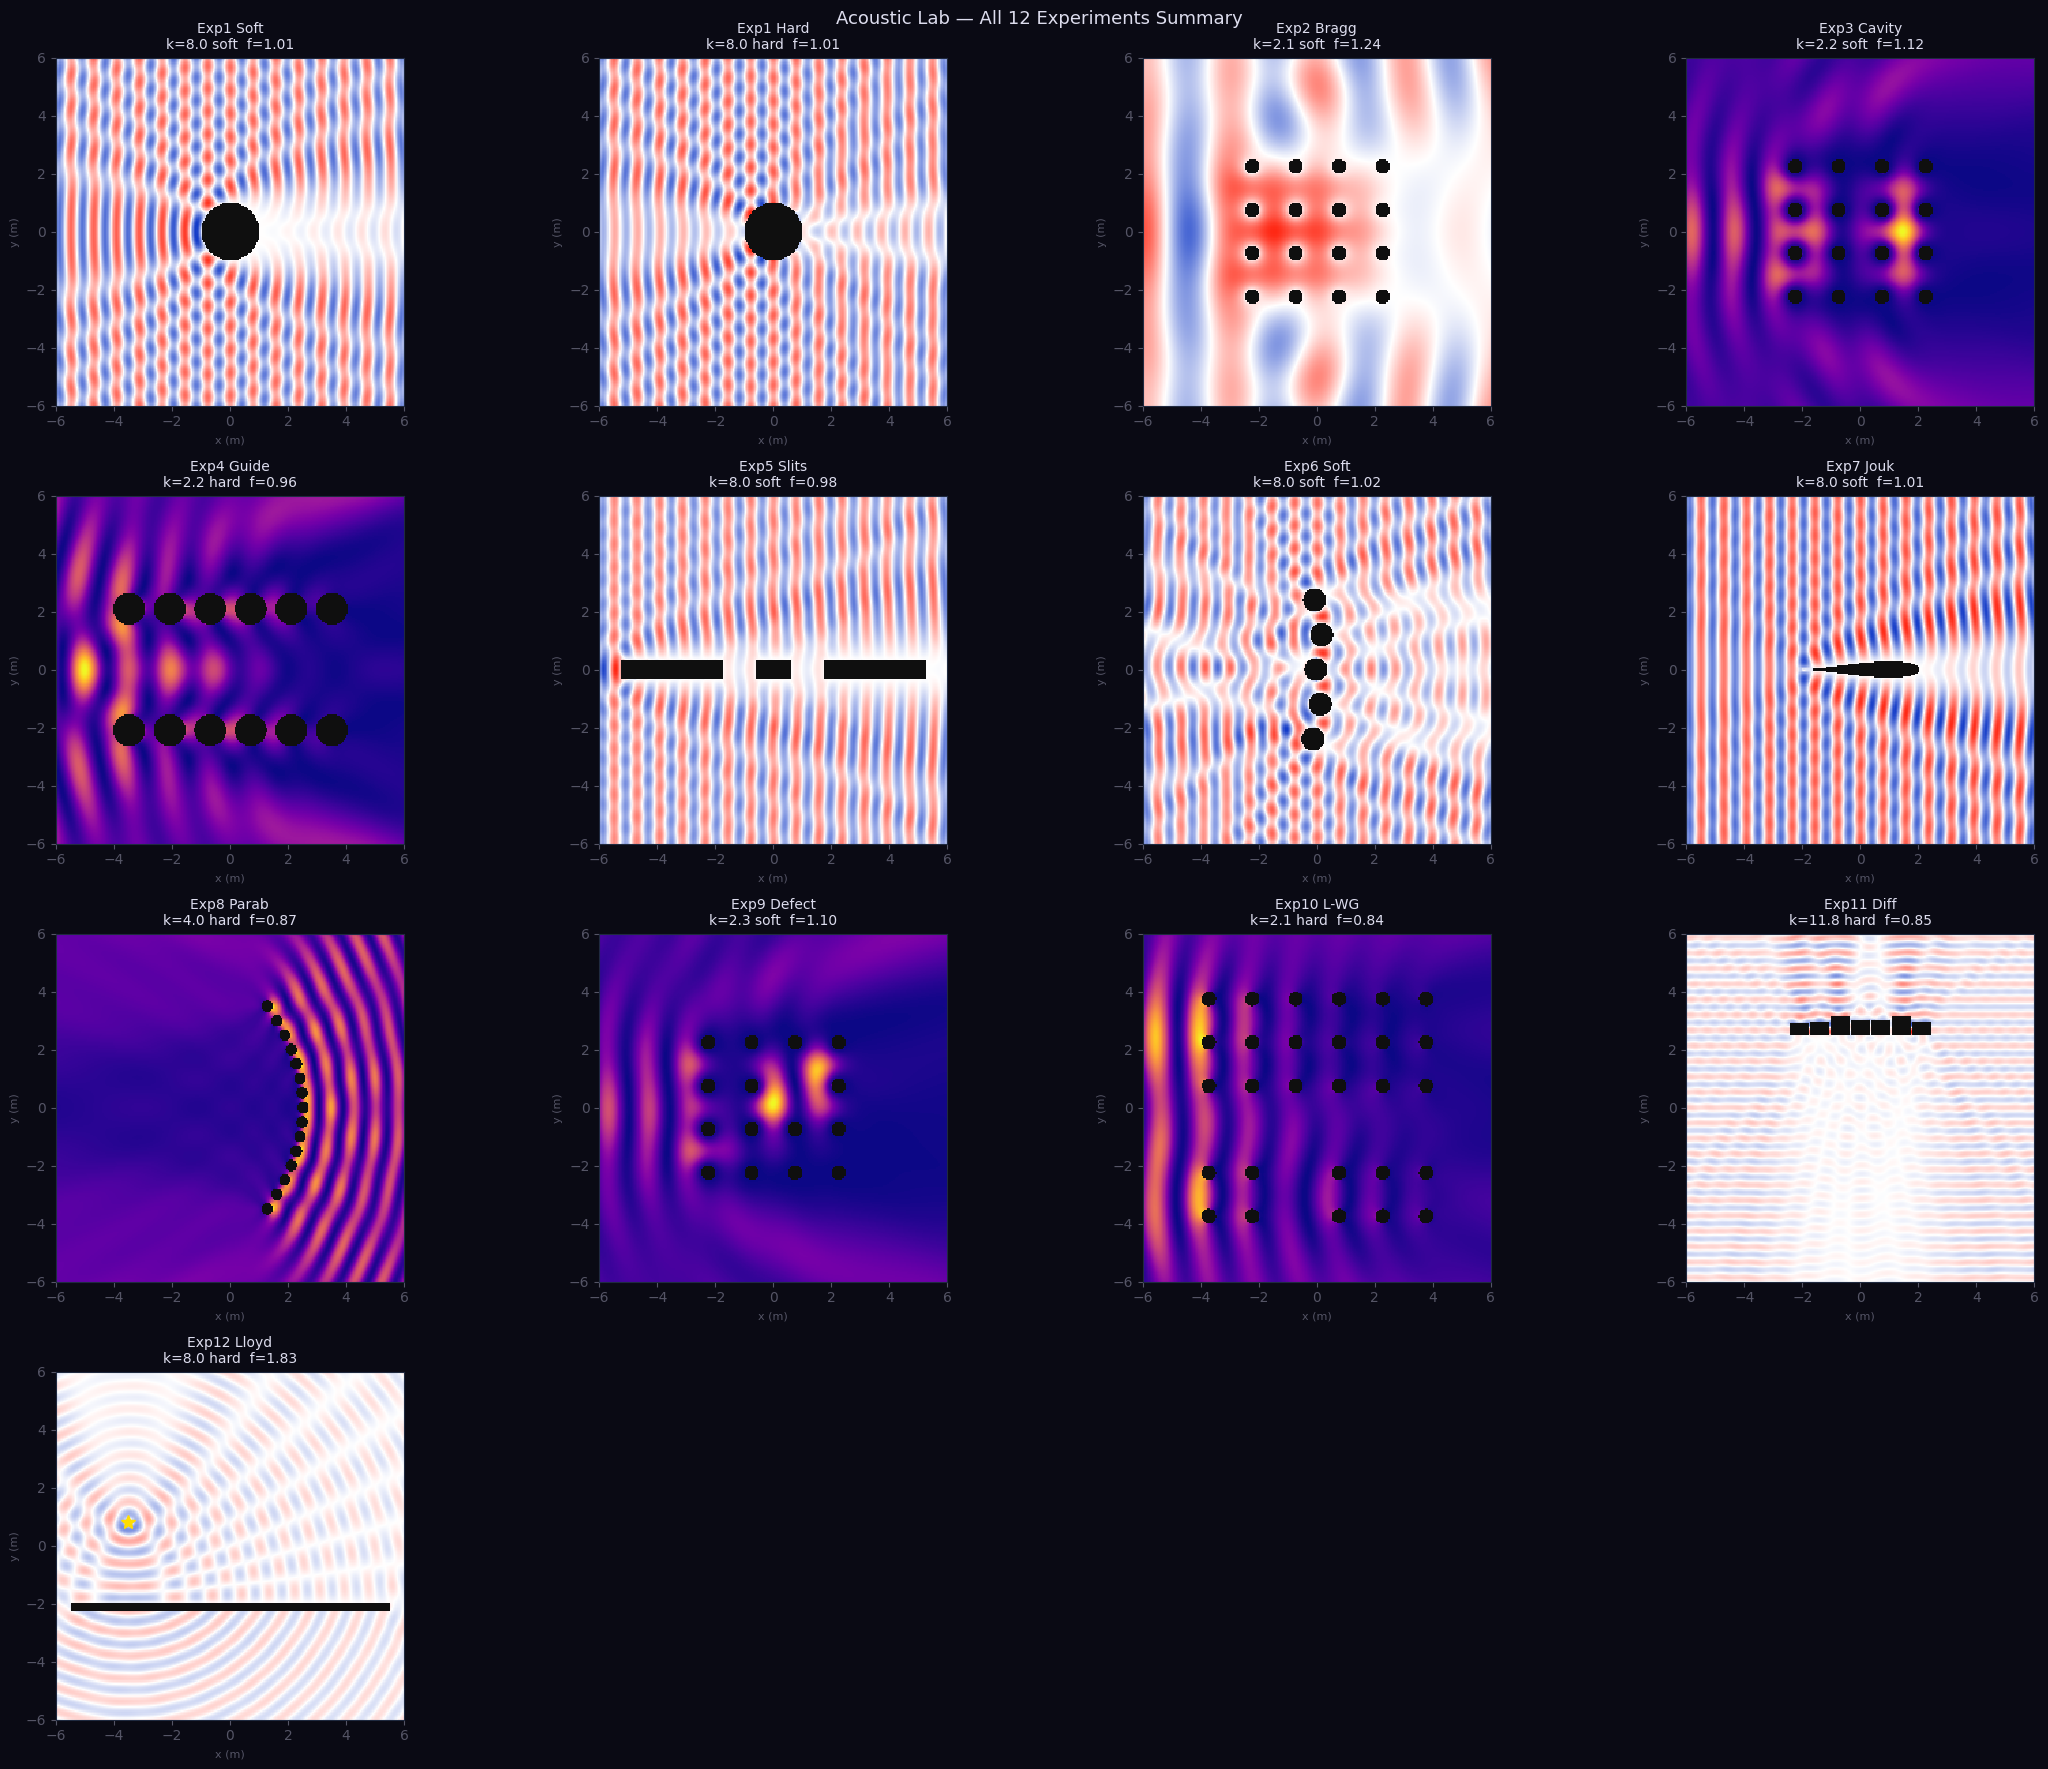

Summary figure saved to exp_summary.png


In [12]:
# ── Summary figure: one panel per experiment (4×4 grid, 12 experiments) ────────
import warnings; warnings.filterwarnings('ignore')

defect_shapes_sum = [s for s in crystal_shapes
                     if not (abs(s['cx'] - 0.75) < 0.1 and abs(s['cy'] - 0.75) < 0.1)]

# L-channel geometry (6×6 crystal, horizontal row 2 + vertical col 2 removed)
_d, _r = 1.5, 0.25
_channel_shapes = [
    {'id': i+1, 'type': 'circle',
     'cx': float((ix - 2.5)*_d), 'cy': float((iy - 2.5)*_d), 'params': {'r': _r}}
    for i, (ix, iy) in enumerate((ix, iy) for iy in range(6) for ix in range(6))
    if not (iy == 2 or (ix == 2 and iy < 2))
]

# Schroeder p=7 geometry (rebuilt locally so this cell is self-contained)
_p, _d_unit, _w_well = 7, 0.40, 0.70
_qr_seq = [(n*n) % _p for n in range(_p)]
_depths = [qr * _d_unit / (_p - 1) for qr in _qr_seq]
_d_max  = max(_depths)
_k_d    = np.pi / _d_max
_schroeder_shapes = [
    {'id': i+1, 'type': 'rect',
     'cx': float((i - (_p-1)/2) * _w_well),
     'cy': float(2.5 + (0.4 + _depths[i])/2),
     'params': {'w': _w_well*0.95, 'h': float(0.4 + _depths[i])}}
    for i in range(_p)
]

# Lloyd's Mirror geometry
_wall_shapes_sum = [{'id':1,'type':'rect','cx':0.0,'cy':-2.125,'params':{'w':11.0,'h':0.25}}]

configs_summary = [
    # (title, shapes, k, alpha_deg, bc, n_panels, solver_type, src_type, src_x, src_y)
    ('Exp1 Soft',   [{'id':1,'type':'circle','cx':0,'cy':0,'params':{'r':1.0}}],
     8.0, 0, 'soft', 200, 'scipy', 'plane', -4.0, 0.0),
    ('Exp1 Hard',   [{'id':1,'type':'circle','cx':0,'cy':0,'params':{'r':1.0}}],
     8.0, 0, 'hard', 200, 'scipy', 'plane', -4.0, 0.0),
    ('Exp2 Bragg',  crystal_shapes, np.pi/1.5, 0, 'soft', 60,
     'gpu_bem' if HAS_GPU_BEM else 'scipy', 'plane', -4.0, 0.0),
    ('Exp3 Cavity', crystal_shapes, 2.2, 0, 'soft', 60,
     'gpu_bem' if HAS_GPU_BEM else 'scipy', 'plane', -4.0, 0.0),
    ('Exp4 Guide',  wg_shapes, 2.2, 0, 'hard', 60,
     'gpu_bem' if HAS_GPU_BEM else 'scipy', 'plane', -4.0, 0.0),
    ('Exp5 Slits',  slit_shapes, 8.0, 0, 'soft', 150, 'scipy', 'plane', -4.0, 0.0),
    ('Exp6 Soft',   barrier_shapes, 8.0, 0, 'soft', 100, 'scipy', 'plane', -4.0, 0.0),
    ('Exp7 Jouk',   jouk_shapes, 8.0, 0, 'soft', 200, 'scipy', 'plane', -4.0, 0.0),
    ('Exp8 Parab',  parab_shapes, 4.0, 180, 'hard', 40, 'scipy', 'plane', -4.0, 0.0),
    ('Exp9 Defect', defect_shapes_sum, 2.3, 0, 'soft', 60,
     'gpu_bem' if HAS_GPU_BEM else 'scipy', 'plane', -4.0, 0.0),
    ('Exp10 L-WG',  _channel_shapes, 2.1, 0, 'hard', 40,
     'gpu_bem' if HAS_GPU_BEM else 'scipy', 'plane', -4.0, 0.0),
    ('Exp11 Diff',  _schroeder_shapes, _k_d, 270, 'hard', 60, 'scipy', 'plane', -4.0, 0.0),
    ('Exp12 Lloyd', _wall_shapes_sum, 8.0, 0, 'hard', 300, 'scipy', 'point', -3.5, 0.8),
]

fig, axes = plt.subplots(4, 4, figsize=(22, 18), facecolor=DARK)
for ax, cfg in zip(axes.ravel(), configs_summary):
    title, shapes, k, a, bc, n, st, src_t, sx, sy = cfg
    res = run(shapes, k, a, bc=bc, n_panels=n, solver_type=st,
              src_type=src_t, src_x=sx, src_y=sy)
    mode = ('intensity' if any(x in title for x in ('Cavity','Guide','Parab','Defect','L-WG'))
            else 're')
    show_field(ax, res, f'{title}\nk={k:.1f} {bc}  f={res["field_power"]:.2f}', mode=mode)

# Hide the 3 unused slots in the 4×4 grid (16 slots for 13 panels)
for ax in axes.ravel()[13:]:
    ax.set_visible(False)

fig.suptitle('Acoustic Lab — All 12 Experiments Summary', color='#dde', fontsize=13)
plt.tight_layout()
plt.savefig('exp_summary.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Summary figure saved to exp_summary.png')

---
## Experiment 10 — Sonic Crystal L-Shaped Waveguide

A 6×6 array of sound-hard cylinders establishes a **full phononic band gap** at k ≈ 2.09 (Bragg condition for spacing d = 1.5 m). An L-shaped channel is carved out by removing one row (horizontal arm) and one column (vertical arm) of rods.

Inside the band gap the surrounding crystal blocks propagation — the only path available to the wave is through the channel. Energy is forced around the **90° corner** without radiating back into the bulk, demonstrating topological-style confinement.

This is the acoustic analogue of a photonic crystal waveguide used in integrated optics: a missing-row defect channel guides light (or here, sound) around sharp bends that would cause large reflections in a conventional waveguide.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Load the 4×4 Crystal preset to get started, then manually extend to 6×6
│    — or just run the code below and observe the field maps
│  Key settings: BC: Hard (rigid rods), Display: |p|² intensity
│  k = 2.1 (inside the Bragg band gap for d=1.5 m):
│    Full 6×6 crystal → nearly zero field behind it (all energy reflected)
│    L-channel crystal → bright horizontal arm + vertical arm energy path
│  Watch: energy enters from the left along the horizontal channel,
│    then turns 90° and exits through the top of the vertical channel
│  Compare k = 1.0 (below gap) — wave passes through the whole crystal freely
│  Compare k = 3.5 (above gap) — multi-mode propagation, no topological guiding
│  Point source bonus: toggle Src: Point and place the source at (-4, 0)
│    to inject energy directly into the horizontal arm mouth
└──────────────────────────────────────────────────────────────────
Full 6×6 crystal : 36 rods
L-chan

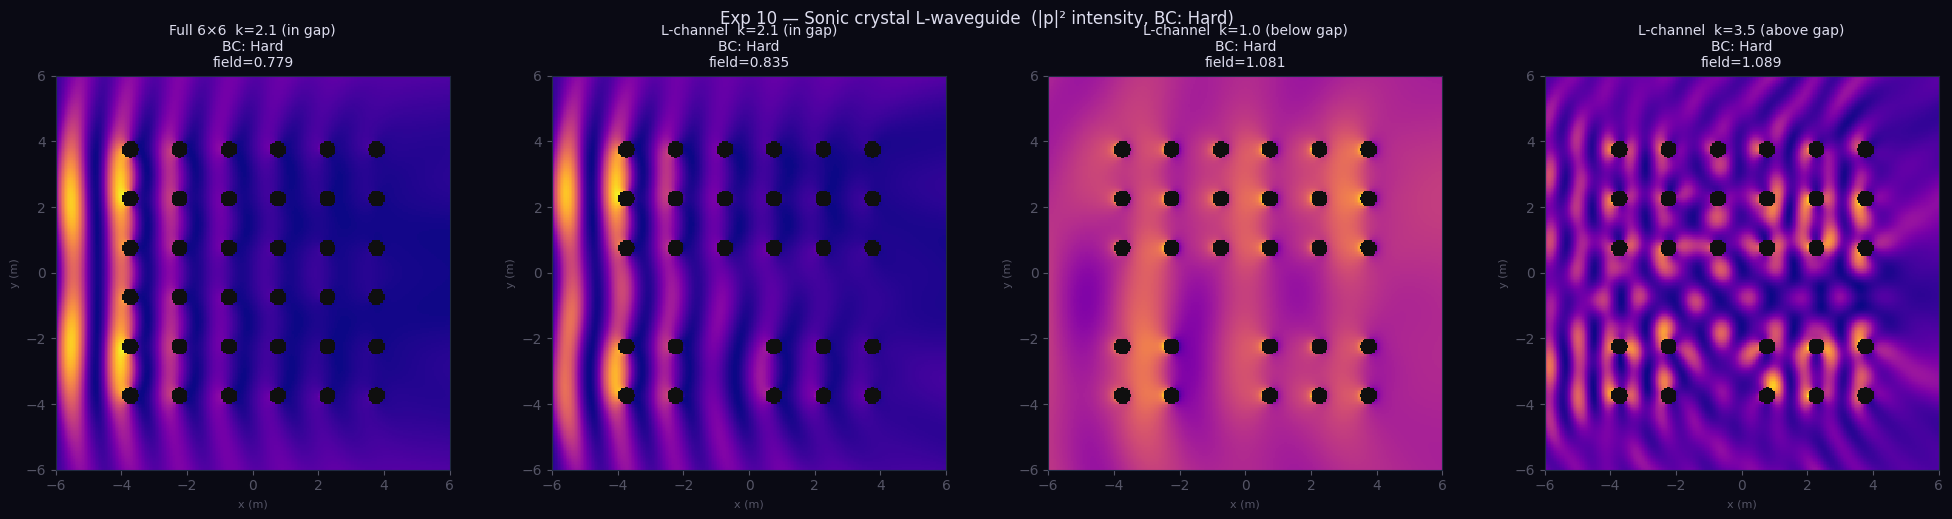

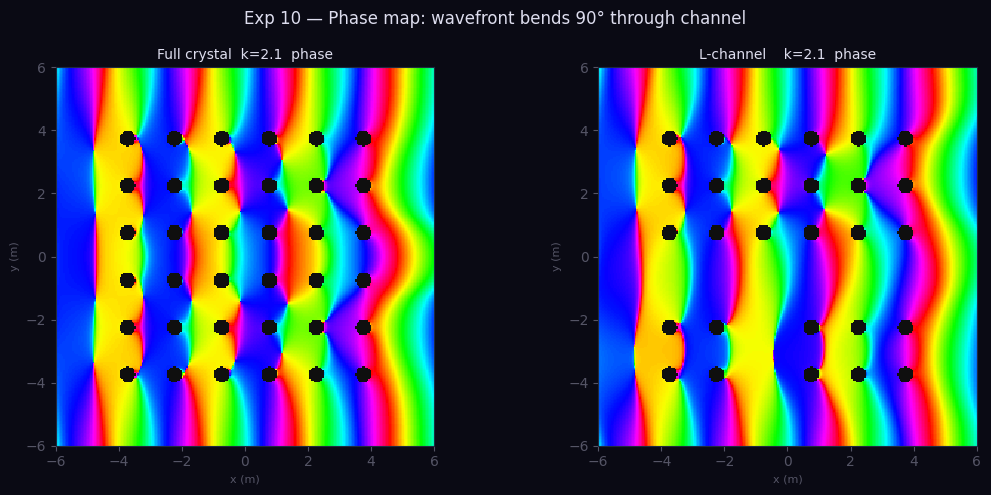

Saved exp10_l_waveguide.png and exp10_l_waveguide_phase.png


In [13]:
lab_recipe([
    'Load the 4×4 Crystal preset to get started, then manually extend to 6×6',
    '  — or just run the code below and observe the field maps',
    'Key settings: BC: Hard (rigid rods), Display: |p|² intensity',
    'k = 2.1 (inside the Bragg band gap for d=1.5 m):',
    '  Full 6×6 crystal → nearly zero field behind it (all energy reflected)',
    '  L-channel crystal → bright horizontal arm + vertical arm energy path',
    'Watch: energy enters from the left along the horizontal channel,',
    '  then turns 90° and exits through the top of the vertical channel',
    'Compare k = 1.0 (below gap) — wave passes through the whole crystal freely',
    'Compare k = 3.5 (above gap) — multi-mode propagation, no topological guiding',
    'Point source bonus: toggle Src: Point and place the source at (-4, 0)',
    '  to inject energy directly into the horizontal arm mouth',
])

# Build 6×6 hard crystal with L-shaped channel removed
d = 1.5
r = 0.25
all_6x6 = [(ix, iy) for iy in range(6) for ix in range(6)]

# L-channel: remove row iy=2 (horizontal arm) and column ix=2 (vertical arm)
#   horizontal arm: iy=2, ix=0..5  (wave enters from left side ix=0)
#   vertical arm  : ix=2, iy=0..2  (connects to horizontal at ix=2,iy=2)
H_ROW = 2        # horizontal channel row index
V_COL = 2        # vertical channel column index
V_MAX_IY = H_ROW # vertical arm runs from iy=0 to iy=H_ROW (inclusive=corner)

def is_channel(ix, iy):
    if iy == H_ROW:             return True   # horizontal arm (full row)
    if ix == V_COL and iy < H_ROW: return True  # vertical arm (above corner)
    return False

channel_shapes = [
    {'id': i+1, 'type': 'circle',
     'cx': float((ix - 2.5)*d), 'cy': float((iy - 2.5)*d), 'params': {'r': r}}
    for i, (ix, iy) in enumerate(all_6x6)
    if not is_channel(ix, iy)
]
full_shapes = [
    {'id': i+1, 'type': 'circle',
     'cx': float((ix - 2.5)*d), 'cy': float((iy - 2.5)*d), 'params': {'r': r}}
    for i, (ix, iy) in enumerate(all_6x6)
]
print(f'Full 6×6 crystal : {len(full_shapes)} rods')
print(f'L-channel crystal: {len(channel_shapes)} rods  ({len(full_shapes)-len(channel_shapes)} removed)')

st = 'gpu_bem' if HAS_GPU_BEM else 'scipy'
k_in_gap  = 2.1
k_below   = 1.0
k_above   = 3.5

configs_10 = [
    (full_shapes,    k_in_gap,  'Full 6×6  k=2.1 (in gap)\nBC: Hard'),
    (channel_shapes, k_in_gap,  'L-channel  k=2.1 (in gap)\nBC: Hard'),
    (channel_shapes, k_below,   'L-channel  k=1.0 (below gap)\nBC: Hard'),
    (channel_shapes, k_above,   'L-channel  k=3.5 (above gap)\nBC: Hard'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor=DARK)
for ax, (shapes, kv, lbl) in zip(axes, configs_10):
    res = run(shapes, kv, 0, bc='hard', n_panels=40, solver_type=st)
    show_field(ax, res, lbl + f'\nfield={res["field_power"]:.3f}', mode='intensity')
    print(f'{lbl.split(chr(10))[0]}: {metrics_text(res)}')

fig.suptitle('Exp 10 — Sonic crystal L-waveguide  (|p|² intensity, BC: Hard)',
             color='#dde')
plt.tight_layout()
plt.savefig('exp10_l_waveguide.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

# Phase map: shows wavefront wrapping around the corner
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5), facecolor=DARK)
r_full = run(full_shapes,    k_in_gap, 0, bc='hard', n_panels=40, solver_type=st)
r_chan = run(channel_shapes, k_in_gap, 0, bc='hard', n_panels=40, solver_type=st)
show_field(axes2[0], r_full, 'Full crystal  k=2.1  phase', mode='phase')
show_field(axes2[1], r_chan, 'L-channel    k=2.1  phase', mode='phase')
fig2.suptitle('Exp 10 — Phase map: wavefront bends 90° through channel',
              color='#dde')
plt.tight_layout()
plt.savefig('exp10_l_waveguide_phase.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved exp10_l_waveguide.png and exp10_l_waveguide_phase.png')

---
## Experiment 11 — Schroeder Diffuser: Hemispherical Scattering

A **Schroeder diffuser** (quadratic residue sequence) is a row of adjacent rectangular wells of varying depths. Each well reflects the incident wave with a different phase shift `φ_n = 2kd_n`, determined by well depth `d_n`. The depths follow a quadratic residue sequence `d_n ∝ n² mod p` for prime `p`, which distributes energy evenly across all angles.

A flat hard wall gives **specular** reflection: the reflected lobe is a mirror image of the incident lobe. The Schroeder diffuser converts specular reflection into **hemispherical diffusion**: the far-field polar plot changes from a single sharp lobe to a nearly flat ring.

Design frequency: `f_d = c/(2 * d_max)` → wavenumber `k_d = π/d_max`. Wells are one wavelength-deep at `k_d`.  
Below `k_d` the pattern is nearly specular (well too shallow to matter); above `k_d` the diffusion is effective.

Real-world use: concert halls, recording studios, home theatre rear walls — anywhere you want scattered reflected sound without a flutter echo.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Add a row of 7 Rect obstacles side-by-side at y ≈ 2, with varying heights:
│    use the depths from the p=7 QR sequence: [0,1,4,2,2,4,1] scaled by 0.3 m
│    Each rect: width w=0.8, height h=0.2+depth; centre x = (i-3)*0.8, y=2+h/2
│  Set α = 270° (wave from above, hitting the top of the diffuser face)
│  BC: Hard, k = design frequency k_d = π/d_max
│  Display: Re(p) — watch the reflected wave fan out rather than bounce back
│  Far-Field polar plot: compare flat wall (single lobe) vs diffuser (flat ring)
│  Sweep k upward past k_d — diffusion improves as λ matches well depths
│  Compare α = 250° (oblique) — specular wall would send reflection to 290°;
│    diffuser scatters evenly regardless of angle
└──────────────────────────────────────────────────────────────────
QR sequence (p=7): [0, 1, 4, 2, 2, 4, 1]
Well depths (m):     ['0.00', '0.07', '0.27', '0.13', '0.13', '0.27', '0.07']
Design k = π/d_max = 11.78  (λ =

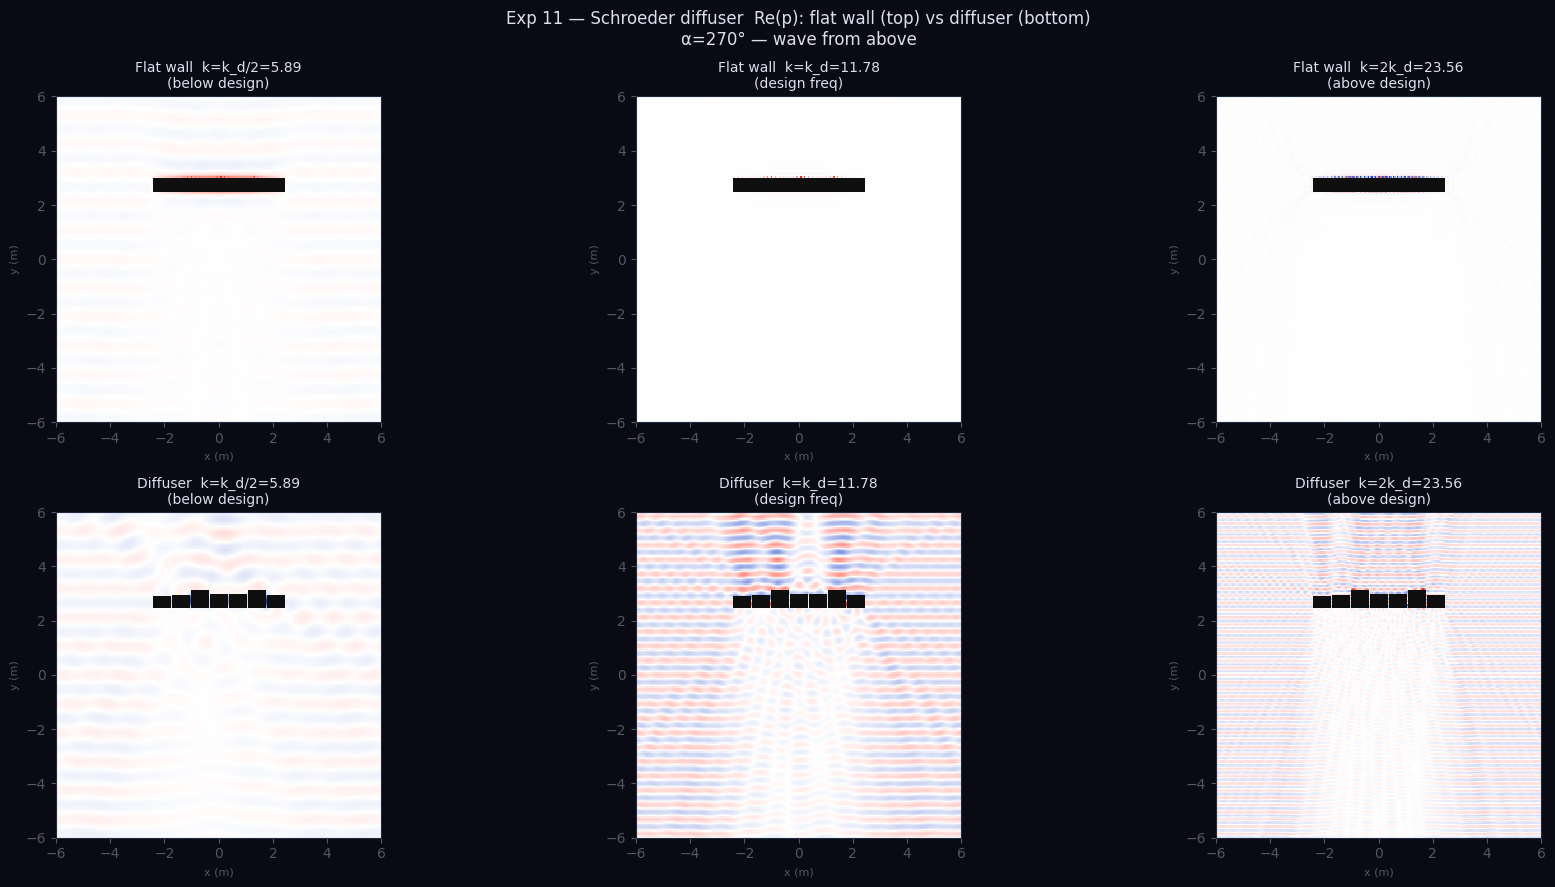

⚠  k=11.8 n_panels=60: ~5.1 panels/λ (unit circle ref) — consider n_panels ≥ 71


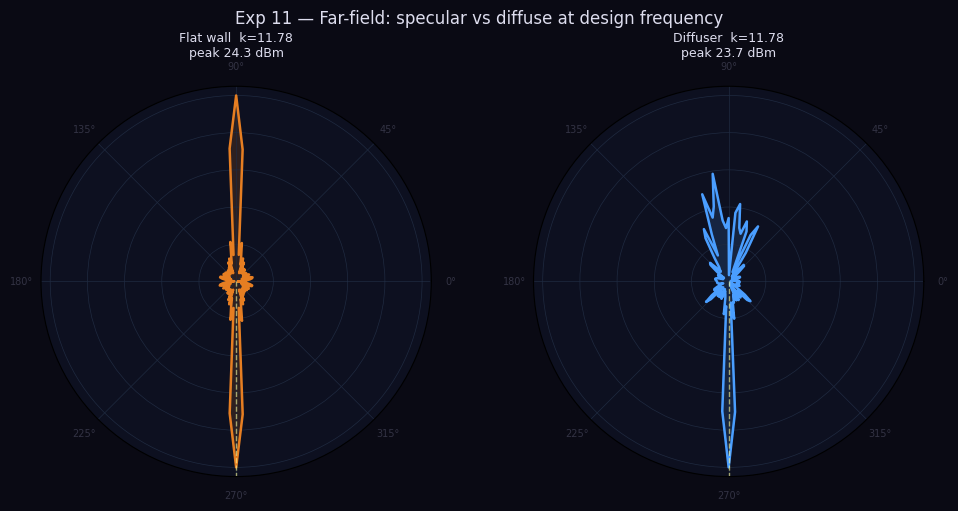

Saved exp11_schroeder_field.png and exp11_schroeder_polar.png


In [14]:
lab_recipe([
    'Add a row of 7 Rect obstacles side-by-side at y ≈ 2, with varying heights:',
    '  use the depths from the p=7 QR sequence: [0,1,4,2,2,4,1] scaled by 0.3 m',
    '  Each rect: width w=0.8, height h=0.2+depth; centre x = (i-3)*0.8, y=2+h/2',
    'Set α = 270° (wave from above, hitting the top of the diffuser face)',
    'BC: Hard, k = design frequency k_d = π/d_max',
    'Display: Re(p) — watch the reflected wave fan out rather than bounce back',
    'Far-Field polar plot: compare flat wall (single lobe) vs diffuser (flat ring)',
    'Sweep k upward past k_d — diffusion improves as λ matches well depths',
    'Compare α = 250° (oblique) — specular wall would send reflection to 290°;',
    '  diffuser scatters evenly regardless of angle',
])

# Schroeder p=7 QR diffuser: depths proportional to n² mod 7
p = 7
qr_seq  = [(n*n) % p for n in range(p)]          # [0,1,4,2,2,4,1]
d_unit  = 0.40                                    # unit depth (m)
w_well  = 0.70                                    # well width (m)
depths  = [qr * d_unit / (p - 1) for qr in qr_seq]
d_max   = max(depths)
k_design = np.pi / d_max if d_max > 0 else 3.0
print(f'QR sequence (p={p}): {qr_seq}')
print(f'Well depths (m):     {[f"{d:.2f}" for d in depths]}')
print(f'Design k = π/d_max = {k_design:.2f}  (λ = {2*np.pi/k_design:.2f} m)')

# Each well is a rectangle; the "back wall" thickness below the well adds to depth
base_h = 0.4        # base block height (continuous back wall)
y_face = 2.5        # y-position of diffuser face (top of wells)

schroeder_shapes = [
    {'id': i+1, 'type': 'rect',
     'cx': float((i - (p-1)/2) * w_well),
     'cy': float(y_face + (base_h + depths[i])/2),
     'params': {'w': w_well*0.95, 'h': float(base_h + depths[i])}}
    for i in range(p)
]
# Flat comparison wall (same total width, same face position)
flat_shapes = [
    {'id': 1, 'type': 'rect',
     'cx': 0.0,
     'cy': float(y_face + (base_h + d_max/2)/2),
     'params': {'w': float(p * w_well), 'h': float(base_h + d_max/2)}}
]

print(f'Diffuser: {len(schroeder_shapes)} wells, face at y={y_face:.1f}')

st = solver.solve.__func__.__doc__  # just checking solver is alive
k_vals_11 = [k_design * 0.5, k_design, k_design * 2.0]
labels_11  = [f'k=k_d/2={k_design*0.5:.2f}\n(below design)',
              f'k=k_d={k_design:.2f}\n(design freq)',
              f'k=2k_d={k_design*2:.2f}\n(above design)']

fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor=DARK)
for col, (kv, lbl) in enumerate(zip(k_vals_11, labels_11)):
    r_flat = run(flat_shapes,      kv, alpha_deg=270, bc='hard', n_panels=80)
    r_diff = run(schroeder_shapes, kv, alpha_deg=270, bc='hard', n_panels=60)
    show_field(axes[0, col], r_flat, f'Flat wall  {lbl}', mode='re')
    show_field(axes[1, col], r_diff, f'Diffuser  {lbl}',  mode='re')
    print(f'k={kv:.2f}  flat: {metrics_text(r_flat)}')
    print(f'k={kv:.2f}  diff: {metrics_text(r_diff)}')

fig.suptitle('Exp 11 — Schroeder diffuser  Re(p): flat wall (top) vs diffuser (bottom)\n'
             'α=270° — wave from above', color='#dde')
plt.tight_layout()
plt.savefig('exp11_schroeder_field.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

# Far-field polar comparison at design frequency
r_flat_d = run(flat_shapes,      k_design, alpha_deg=270, bc='hard', n_panels=80)
r_diff_d = run(schroeder_shapes, k_design, alpha_deg=270, bc='hard', n_panels=60)

fig2 = plt.figure(figsize=(10, 5), facecolor=DARK)
ax_fp = fig2.add_subplot(1, 2, 1, projection='polar')
ax_dp = fig2.add_subplot(1, 2, 2, projection='polar')
show_polar(ax_fp, r_flat_d, f'Flat wall  k={k_design:.2f}', '#e67e22')
show_polar(ax_dp, r_diff_d, f'Diffuser  k={k_design:.2f}',  '#4a9eff')
fig2.suptitle('Exp 11 — Far-field: specular vs diffuse at design frequency',
              color='#dde')
plt.tight_layout()
plt.savefig('exp11_schroeder_polar.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved exp11_schroeder_field.png and exp11_schroeder_polar.png')

---
## Experiment 12 — Lloyd's Mirror: Hyperbolic Interference Fringes

Place a cylindrical line source (point source) close to a long, flat, rigid wall. The wall creates a **mirror image source** at the reflected position. The two sources — real and image — radiate coherently and interfere.

**Sound-hard BC** (rigid wall): the reflected wave is **in-phase** with the incident wave (no phase reversal on reflection). Constructive interference occurs along hyperbolas where path difference `Δr = r₁ − r₂ = nλ`. The result is a distinctive set of **hyperbola-shaped bright fringes** arching away from the wall.

**Sound-soft BC** (pressure-release wall): the reflected wave undergoes a **180° phase reversal**. The bright and dark fringes swap — constructive becomes destructive and vice versa. Crucially, there is always a **pressure null exactly at the wall surface** (matching the Dirichlet BC `p = 0`).

The fringe spacing near the wall is `Δy ≈ λ / (2 sin θ)` where `θ` is the angle from the wall. Fringes are densest close to the wall-normal and open up at grazing angles.

This is the acoustic analogue of Lloyd's Mirror in optics (first demonstrated 1834), where coherent light from a slit and its reflection in a mirror produce the same hyperbolic fringe pattern. It is also the mechanism behind shallow-water acoustic multipath propagation and architectural flutter echoes.

┌─ Lab UI Recipe ──────────────────────────────────────────────────
│  Load the "Lloyd's Mirror" preset (flat hard wall + point source)
│    — sets BC: Hard, Src: Point at (-3.5, 0.8), wall rect at (0, -2.2), k=8.0
│  Display: Re(p) — observe hyperbolic bright fringes arching above the wall
│  Phase map: toggle Display to Phase — see the wavefront bending around fringes
│  Toggle BC: Hard → BC: Soft:
│    Hard: bright fringe pattern; constructive at the wall face (green/red bands)
│    Soft: dark null runs along the entire wall; fringes shift by λ/2
│  Try moving the ★ source marker closer to the wall (drag in the field view)
│    — fringes become denser as the source-wall distance decreases
│  Try k = 4.0: longer wavelength → fewer, wider fringes
│  Try k = 16.0: many tight fringes; classical ray-optics limit visible
│  The Far-Field polar plot shows two symmetric lobes from real + image sources
└──────────────────────────────────────────────────────────────────
Real source  : (-3.5, 

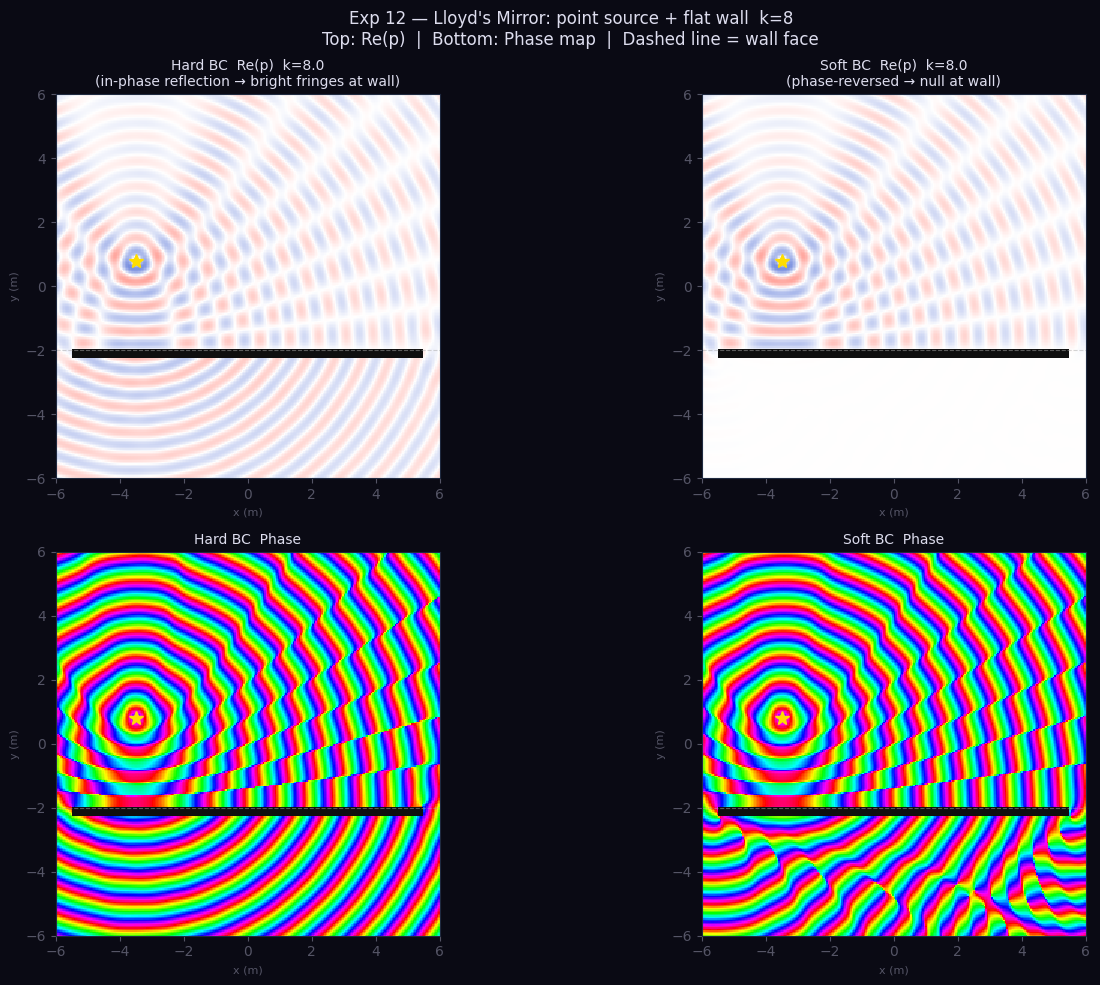

k=4.0: field=2.068  scatter=0.548  solver=scipy [hard]
k=8.0: field=1.824  scatter=0.545  solver=scipy [hard]
k=12.0: field=2.017  scatter=0.543  solver=scipy [hard]
k=16.0: field=1.873  scatter=0.537  solver=scipy [hard]


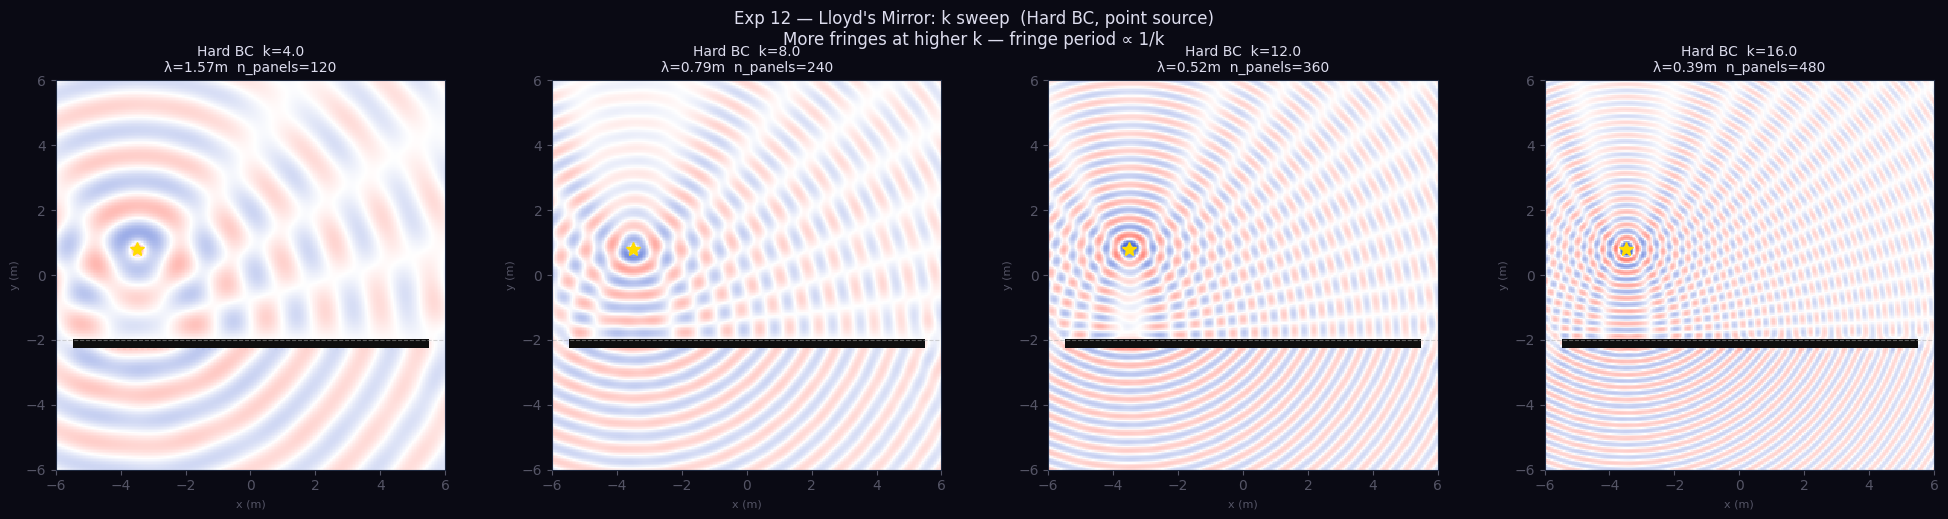

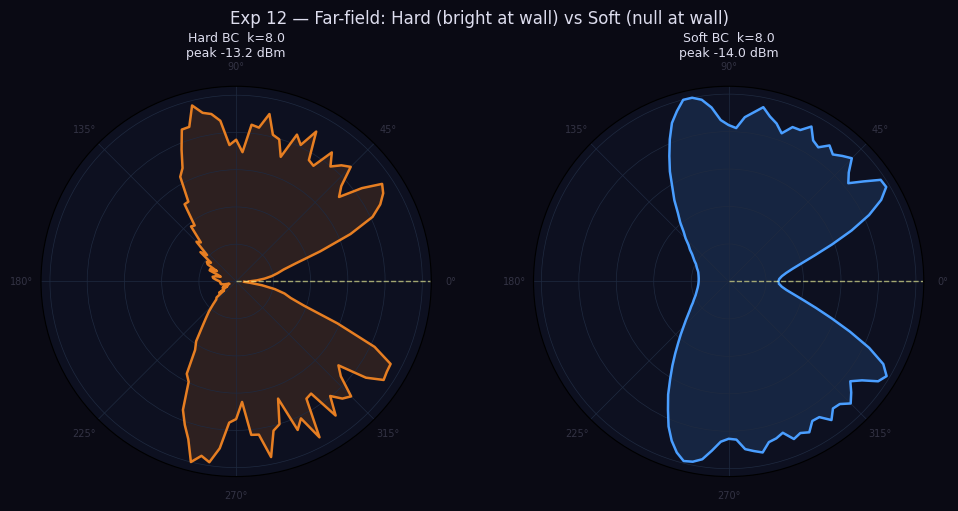


Saved exp12_lloyds_mirror_field.png, exp12_lloyds_mirror_ksweep.png,
       exp12_lloyds_mirror_polar.png

Analytical fringe positions at x=0 (normal from source):
  n=-3  y=0.006 m  (Δr=-2.356 m)
  n=-2  y=-0.710 m  (Δr=-1.571 m)
  n=-1  y=-1.368 m  (Δr=-0.785 m)


In [15]:
lab_recipe([
    'Load the "Lloyd\'s Mirror" preset (flat hard wall + point source)',
    '  — sets BC: Hard, Src: Point at (-3.5, 0.8), wall rect at (0, -2.2), k=8.0',
    'Display: Re(p) — observe hyperbolic bright fringes arching above the wall',
    'Phase map: toggle Display to Phase — see the wavefront bending around fringes',
    'Toggle BC: Hard → BC: Soft:',
    '  Hard: bright fringe pattern; constructive at the wall face (green/red bands)',
    '  Soft: dark null runs along the entire wall; fringes shift by λ/2',
    'Try moving the ★ source marker closer to the wall (drag in the field view)',
    '  — fringes become denser as the source-wall distance decreases',
    'Try k = 4.0: longer wavelength → fewer, wider fringes',
    'Try k = 16.0: many tight fringes; classical ray-optics limit visible',
    'The Far-Field polar plot shows two symmetric lobes from real + image sources',
])

# ── Scene: flat rigid wall + point source ─────────────────────────────────────
# Wall: thin horizontal rectangle spanning the full width at y = -2.0
wall_y   = -2.0
wall_shapes = [
    {'id': 1, 'type': 'rect', 'cx': 0.0, 'cy': wall_y - 0.125,
     'params': {'w': 11.0, 'h': 0.25}}
]

# Point source position
src_x, src_y = -3.5, 0.8   # above the wall
k_lm = 8.0

# Image source position (mirror of src_y about wall_y)
img_y = 2 * wall_y - src_y
print(f'Real source  : ({src_x:.1f}, {src_y:.1f})')
print(f'Image source : ({src_x:.1f}, {img_y:.1f})  (reflected about y={wall_y})')
print(f'Source-wall distance h = {src_y - wall_y:.2f} m')
lam_lm = 2 * np.pi / k_lm
print(f'λ = {lam_lm:.2f} m  →  h/λ = {(src_y - wall_y)/lam_lm:.2f}')
print(f'Expected fringe period near wall: Δy ≈ λ/(2h/D) ...')

# Run Hard and Soft BC
r_hard_lm = run(wall_shapes, k_lm, alpha_deg=0, bc='hard', n_panels=300,
                src_type='point', src_x=src_x, src_y=src_y)
r_soft_lm = run(wall_shapes, k_lm, alpha_deg=0, bc='soft', n_panels=300,
                src_type='point', src_x=src_x, src_y=src_y)

print(f'\nHard BC: {metrics_text(r_hard_lm)}')
print(f'Soft BC: {metrics_text(r_soft_lm)}')

# ── 4-panel comparison: Re(p) and phase for both BCs ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=DARK)

show_field(axes[0, 0], r_hard_lm,
           f'Hard BC  Re(p)  k={k_lm}\n(in-phase reflection → bright fringes at wall)')
show_field(axes[0, 1], r_soft_lm,
           f'Soft BC  Re(p)  k={k_lm}\n(phase-reversed → null at wall)')
show_field(axes[1, 0], r_hard_lm,
           f'Hard BC  Phase', mode='phase')
show_field(axes[1, 1], r_soft_lm,
           f'Soft BC  Phase', mode='phase')

# Mark wall position with a dashed line
for ax in axes.ravel():
    ax.axhline(wall_y, color='#aaa', lw=0.8, ls='--', alpha=0.5)

fig.suptitle('Exp 12 — Lloyd\'s Mirror: point source + flat wall  k=8\n'
             'Top: Re(p)  |  Bottom: Phase map  |  Dashed line = wall face',
             color='#dde')
plt.tight_layout()
plt.savefig('exp12_lloyds_mirror_field.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

# ── k sweep: watch fringe count scale with wavelength ─────────────────────────
k_sweep = [4.0, 8.0, 12.0, 16.0]
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5), facecolor=DARK)
for ax, kv in zip(axes2, k_sweep):
    rv = run(wall_shapes, kv, alpha_deg=0, bc='hard', n_panels=int(kv * 30),
             src_type='point', src_x=src_x, src_y=src_y)
    show_field(ax, rv, f'Hard BC  k={kv}\nλ={2*np.pi/kv:.2f}m  n_panels={int(kv*30)}')
    ax.axhline(wall_y, color='#aaa', lw=0.8, ls='--', alpha=0.5)
    print(f'k={kv}: {metrics_text(rv)}')

fig2.suptitle('Exp 12 — Lloyd\'s Mirror: k sweep  (Hard BC, point source)\n'
              'More fringes at higher k — fringe period ∝ 1/k', color='#dde')
plt.tight_layout()
plt.savefig('exp12_lloyds_mirror_ksweep.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

# ── Far-field polar: Hard vs Soft ─────────────────────────────────────────────
fig3 = plt.figure(figsize=(10, 5), facecolor=DARK)
ax_ph = fig3.add_subplot(1, 2, 1, projection='polar')
ax_ps = fig3.add_subplot(1, 2, 2, projection='polar')
show_polar(ax_ph, r_hard_lm, f'Hard BC  k={k_lm}', '#e67e22')
show_polar(ax_ps, r_soft_lm, f'Soft BC  k={k_lm}', '#4a9eff')
fig3.suptitle('Exp 12 — Far-field: Hard (bright at wall) vs Soft (null at wall)',
              color='#dde')
plt.tight_layout()
plt.savefig('exp12_lloyds_mirror_polar.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

print('\nSaved exp12_lloyds_mirror_field.png, exp12_lloyds_mirror_ksweep.png,')
print('       exp12_lloyds_mirror_polar.png')

# ── Analytical verification: fringe positions ─────────────────────────────────
# Constructive (Hard): path difference Δr = r_real - r_image = nλ
# r_real  = sqrt((x - src_x)² + (y - src_y)²)
# r_image = sqrt((x - src_x)² + (y - img_y)²)
# Bright fringes at y values where r_real - r_image ≈ n * 2π/k_lm
print(f'\nAnalytical fringe positions at x=0 (normal from source):')
x_probe = 0.0
for n in range(-3, 4):
    # solve r1 - r2 = n*lam analytically: hyperbola with foci at (src_x,src_y) and (src_x,img_y)
    # at x=x_probe: y s.t. sqrt((x_probe-src_x)²+(y-src_y)²) - sqrt((x_probe-src_x)²+(y-img_y)²) = n*lam
    dx2 = (x_probe - src_x)**2
    target = n * lam_lm
    # numerical root
    from scipy.optimize import brentq
    def fringe_fn(y):
        return (np.sqrt(dx2+(y-src_y)**2) - np.sqrt(dx2+(y-img_y)**2)) - target
    try:
        y_fr = brentq(fringe_fn, wall_y + 0.01, 5.9)
        print(f'  n={n:+d}  y={y_fr:.3f} m  (Δr={target:.3f} m)')
    except ValueError:
        pass